<a href="https://colab.research.google.com/github/Mriano29/hotel_demand_forecasting_system/blob/main/data/base_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación del Dataset

Este proyecto prepara el dataset para desarrollar un sistema accesible de Gestión de Ingresos para hoteles medianos e independientes, que generalmente carecen de herramientas avanzadas para optimizar sus ingresos.

Se realizarán las siguientes etapas:
- Exploración inicial del dataset
- Limpieza de datos (nulos, duplicados, tipos, outliers)
- Feature engineering
- Análisis de correlación y selección de variables
- Evaluación de la calidad del dataset final

El objetivo final es obtener un dataset limpio y optimizado para:
- Predicción de cancelaciones
- Estimación de precios (ADR)
- Modelado de ocupación

##**1.0 — Exploración inicial**

### 1.1 — Carga de datos

Se carga el dataset desde una fuente externa (GitHub) para garantizar reproducibilidad.

In [119]:
import pandas as pd

url = "https://raw.githubusercontent.com/Mriano29/hotel_demand_forecasting_system/refs/heads/main/data/raw_data/hotel_booking.csv"

df = pd.read_csv(url)

### 1.2 — Visualización de las primeras filas

Se visualizan las primeras filas del dataset para realizar una validación preliminar de la carga de datos y comprender la estructura general de la información disponible.

In [120]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


### 1.3 — Forma del dataset

Se analiza la dimensión inicial del dataset para conocer el volumen total de información disponible antes de aplicar cualquier transformación o limpieza.

In [121]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 119390
Columnas: 36


### 1.4 — Información general del dataset

Se utiliza el método `info()` para obtener una visión estructural completa del dataset y evaluar la calidad inicial de los datos.

A partir de esta inspección se detectaron varios aspectos relevantes para las siguientes fases del proyecto:

* Presencia de valores nulos en las variables `children`, `country`, `agent` y `company`

* Variables temporales almacenadas como texto

* Columnas con información personal identificable (PII)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 1.5 — Estadísticas descriptivas iniciales

Se calculan estadísticas descriptivas sobre todas las variables del dataset mediante `describe(include='all')`, con el objetivo de obtener una visión global del comportamiento de los datos antes de iniciar el proceso de limpieza y transformación.



* La variable `is_canceled` presenta una media de 0.37, lo que indica que aproximadamente el 37% de las reservas fueron canceladas

* La variable `lead_time` alcanza valores máximos de hasta 737 días, reflejando reservas realizadas con una antelación muy elevada

* La variable `adr` presenta valores negativos y máximos extremadamente altos (5400), lo que sugiere la existencia de anomalías y posibles outliers que deberán analizarse posteriormente

* Variables como `adults`, `stays_in_week_nights` o `stays_in_weekend_nights` contienen valores máximos poco habituales, lo que requiere validación durante la fase de limpieza

* En las variables categóricas se observa una fuerte concentración en determinadas categorías, como `City Hotel` en hotel o `Transient` en customer_type

* También se detecta la presencia de columnas con una elevada cardinalidad, como `email`, `phone-number` o `name`, que posteriormente serán eliminadas por no aportar valor predictivo y contener información personal identificable

In [123]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390,119390,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,4,NaN,NaN,NaN,3,926,81503,115889,119390,9000
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,Transient,NaN,NaN,NaN,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,422-804-6403,************3627
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,89613,NaN,NaN,NaN,75166,1461,48,6,1,28
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,101.831122,0.062518,0.571363,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,50.535790,0.245291,0.792798,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,-6.380000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,69.290000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,94.575000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,126.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN


### 1.6 — Análisis de valores nulos

Se realiza un análisis específico de los valores faltantes presentes en el dataset con el objetivo de identificar qué variables contienen datos incompletos y cuantificar su impacto sobre el total de registros.

Los resultados muestran que únicamente cuatro variables presentan valores nulos:

* `company`: 112.593 valores faltantes.
* `agent`: 16.340 valores faltantes.
* `country`: 488 valores faltantes.
* `children`: 4 valores faltantes.

La elevada cantidad de nulos en `company` y `agent` resulta coherente con la naturaleza del negocio, ya que muchas reservas fueron realizadas directamente por clientes particulares sin intermediarios ni empresas asociadas.

Por otro lado, los valores faltantes en `country` y `children` representan una proporción muy reducida respecto al total del dataset, por lo que podrán tratarse posteriormente mediante estrategias de imputación sencillas.

In [124]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4


### 1.7 — Detección de valores duplicados

In [125]:
duplicated_rows = df.duplicated().sum()

print(f"Registros duplicados: {duplicated_rows}")

Registros duplicados: 0


### 1.8 — Validación de consistencia lógica en registros de reservas

En esta sección se evalúa la coherencia interna de los registros del dataset con el objetivo de detectar observaciones que, aunque no presentan valores nulos, no son consistentes desde un punto de vista operativo.

Este tipo de validación permite identificar registros que no representan situaciones reales de negocio, como reservas sin huéspedes o sin estancia efectiva, y que por tanto pueden introducir ruido en los modelos predictivos.

La eliminación de estas inconsistencias contribuye a mejorar la calidad del dataset y a garantizar que el análisis posterior se base en datos coherentes con la realidad del sector hotelero.

#### 1.8.1 — Detección de reservas sin huéspedes

Se identifican 180 registros en los que no se especifica ningún huésped asociado a la reserva (`adults`, `children` y `babies` igual a cero). Estas observaciones no son coherentes con el proceso de reserva hotelera y se consideran inválidas para el análisis.

In [126]:
no_guests = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

print(f"Reservas sin huéspedes: {no_guests.shape[0]}")

Reservas sin huéspedes: 180


#### 1.8.2 — Detección de reservas con sin noches de estancia

Se detectan 715 registros con duración de estancia igual a cero, donde no se registran noches en `stays_in_week_nights` ni en `stays_in_weekend_nights`. Estas observaciones no representan estancias reales y se eliminan del dataset.

In [127]:
zero_nights = df[
    (df["stays_in_week_nights"] == 0) &
    (df["stays_in_weekend_nights"] == 0)
]

print(f"Reservas con 0 noches: {zero_nights.shape[0]}")

Reservas con 0 noches: 715


### 1.9 — Análisis de anomalías y valores extremos en ADR

En esta sección se analiza en profundidad la variable `adr` (Average Daily Rate), una de las variables más relevantes del dataset ya que representa el precio medio diario pagado por cada reserva hotelera.

El objetivo de este análisis es comprender la distribución de los precios, identificar valores extremos y detectar posibles anomalías que puedan afectar al rendimiento de los modelos predictivos.

Dado que `adr` es una variable clave en problemas de Revenue Management y predicción de ingresos, su tratamiento requiere especial cuidado, evitando eliminaciones automáticas que puedan eliminar información válida del negocio (como habitaciones premium o temporadas de alta demanda).

#### 1.9.1 — Distribución estadística y análisis de percentiles de ADR

Se analiza la distribución de la variable adr mediante estadísticas descriptivas y percentiles para comprender su comportamiento general.

Los resultados muestran una media de 101.83 y una mediana de 94.57, lo que indica una ligera asimetría hacia valores altos.

El análisis de percentiles revela que el 95% de las reservas tiene un ADR inferior a 193.5,
el 99% está por debajo de 252,
y el 99.9% no supera 326.2.

Sin embargo, se observa un valor máximo de 5400, muy alejado del resto de la distribución, lo que sugiere la presencia de valores extremos que deben ser analizados con precaución en el contexto del negocio hotelero.

In [128]:
df["adr"].describe(percentiles=[0.95, 0.99, 0.999])

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
50%,94.575000
95%,193.500000
99%,252.000000
99.9%,326.201630
max,5400.000000


#### 1.9.2 — Detección de valores negativos en ADR

Se analiza la existencia de valores negativos en la variable `adr`, ya que desde un punto de vista económico un precio diario negativo no tiene sentido en un contexto hotelero.

El análisis detecta un único registro con valor negativo, el cual se considera una anomalía o error de registro.

Este tipo de observaciones será eliminado durante la fase de limpieza para evitar distorsiones en el modelado predictivo.

In [129]:
negative_adr = df[df["adr"] < 0]

print(f"Reservas con ADR negativo: {negative_adr.shape[0]}")

Reservas con ADR negativo: 1


### 1.10 — Análisis de variables temporales del dataset

Se analizan las variables relacionadas con la fecha de llegada con el objetivo de comprender cómo está estructurada la información temporal en el dataset.

El dataset no contiene una variable de fecha unificada, sino que la información temporal se encuentra fragmentada en varias columnas: año, mes, semana del año y día del mes.

Este formato requiere una transformación previa antes de poder realizar análisis temporales avanzados o integrar el dataset con fuentes externas como AEMET, ISTAC o AENA, que trabajan con fechas completas y series temporales estándar.

In [130]:
print("Año de llegada (arrival_date_year):")
print(df["arrival_date_year"].unique())

print("\nMes de llegada (arrival_date_month):")
print(df["arrival_date_month"].unique())

print("\nSemana del año (arrival_date_week_number) - muestra:")
print(df["arrival_date_week_number"].unique()[:20])

print("\nDía del mes (arrival_date_day_of_month) - muestra:")
print(df["arrival_date_day_of_month"].unique()[:20])

Año de llegada (arrival_date_year):
[2015 2016 2017]

Mes de llegada (arrival_date_month):
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']

Semana del año (arrival_date_week_number) - muestra:
[27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]

Día del mes (arrival_date_day_of_month) - muestra:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


### 1.11 — Análisis de tipos de variables

Se realiza un análisis de los tipos de datos presentes en el dataset con el objetivo de comprender cómo se representa cada variable y detectar posibles inconsistencias entre el tipo técnico almacenado y el significado real de la información.

#### 1.11.1 — Inspección general de tipos de datos

Se inspeccionan los tipos de datos almacenados en cada columna del dataset para identificar variables numéricas, categóricas y temporales.

In [131]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


#### 1.11.2 — Clasificación de variables por tipo

Se agrupan las variables según su tipo de dato para facilitar el análisis estructural del dataset.

In [132]:
categorical_columns = df.select_dtypes(include=["object"]).columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Variables categóricas potenciales:")
print(categorical_columns)

print("\nVariables numéricas:")
print(numeric_columns)

Variables categóricas potenciales:
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date', 'name', 'email', 'phone-number',
       'credit_card'],
      dtype='object')

Variables numéricas:
Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')


#### 1.11.3 — Identificación de variables con representación semántica especial

Se identifican variables cuya representación técnica no refleja correctamente su significado real dentro del contexto del negocio hotelero.

Algunas columnas almacenadas como valores numéricos representan en realidad identificadores categóricos y no magnitudes continuas. Este es el caso de variables como `agent` y `company`, que identifican intermediarios y empresas asociadas a determinadas reservas.

### 1.12 — Informe final de salud del dataset



Se realiza un informe global del estado del dataset tras las fases iniciales de carga, exploración y limpieza, con el objetivo de consolidar en una única vista las principales métricas estructurales y de calidad de los datos.

Este resumen permite verificar de forma rápida el impacto de las transformaciones realizadas y confirmar que el dataset se encuentra en condiciones adecuadas para las siguientes fases de análisis y modelado.

El informe muestra los siguientes resultados:

* El dataset mantiene un total de 119.390 registros y 36 variables, lo que confirma que no se ha producido pérdida estructural de información relevante durante el proceso de limpieza

* No se detectan registros duplicados, lo que garantiza la integridad de las observaciones

* Se observa la presencia de valores nulos en el dataset original

* La variable adr presenta un valor mínimo negativo (-6.38) y un valor máximo extremadamente elevado (5400), lo que refuerza la necesidad del análisis específico de outliers

In [133]:
health_report = pd.DataFrame({
    "Métrica": [
        "Registros",
        "Variables",
        "Duplicados",
        "Valores nulos",
        "ADR mínimo",
        "ADR máximo"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        round(df["adr"].min(), 2),
        round(df["adr"].max(), 2)
    ]
})

health_report

,Métrica,Valor
0,Registros,119390.00
1,Variables,36.00
2,Duplicados,0.00
3,Valores nulos,129425.00
4,ADR mínimo,-6.38
5,ADR máximo,5400.00


## **2.0 — Limpieza**


En esta sección se realiza el proceso de limpieza y depuración del dataset con el objetivo de garantizar la calidad, coherencia y consistencia de los datos antes de su utilización en las fases de análisis y modelado.

El proceso incluye la eliminación de duplicados, tratamiento de valores nulos, detección y eliminación de inconsistencias lógicas, tratamiento de valores extremos en variables críticas, corrección de tipos de datos y eliminación de variables no relevantes o sensibles.

### 2.1 — Eliminación de registros duplicados

El análisis inicial confirma que no existen registros duplicados en el dataset, lo que indica una buena calidad estructural de los datos originales.

Por este motivo, no se requiere la eliminación de ninguna observación en esta etapa, aunque se mantiene esta validación como parte del proceso estándar de limpieza de datos en pipelines de Machine Learning.

In [134]:
duplicated_rows = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicated_rows}")

Registros duplicados encontrados: 0


### 2.1 — Manejo de valores nulos

Se procede al tratamiento de los valores nulos detectados previamente en el dataset, aplicando estrategias específicas en función del significado de cada variable.

Las variables `children` y `country` se imputan con valores por defecto (0 y "Unknown" respectivamente), ya que su ausencia puede interpretarse como la no presencia de información adicional o desconocimiento del dato en el momento de la reserva.

Las variables `agent` y `company`, relacionadas con intermediarios de reserva, se imputan con 0, representando la ausencia de agente o empresa asociada.

Este enfoque permite preservar la totalidad de los registros del dataset sin introducir distorsiones significativas en la distribución de los datos, manteniendo la coherencia del conjunto de información para fases posteriores de análisis y modelado.

In [135]:
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

df.isnull().sum()[df.isnull().sum() > 0]

,0


### 2.2 — Eliminación de reservas sin huéspedes

Se eliminan aquellos registros en los que no existe ningún huésped asociado a la reserva (adultos, niños y bebés iguales a cero).

Estas observaciones no son coherentes con el proceso real de reserva hotelera, por lo que se consideran registros inválidos y se eliminan del dataset.

In [136]:
df = df[
    ~(
        (df["adults"] == 0) &
        (df["children"] == 0) &
        (df["babies"] == 0)
    )
]

df.shape

(119210, 36)

### 2.3 — Eliminación de reservas sin noches de estancia

Se eliminan las reservas en las que no se registra ninguna noche de estancia, es decir, aquellas donde tanto las noches entre semana como las de fin de semana son igual a cero.

Estas observaciones no representan estancias reales en el hotel y, por tanto, no aportan información útil para el modelado.

In [137]:
df = df[
    ~(
        (df["stays_in_week_nights"] == 0) &
        (df["stays_in_weekend_nights"] == 0)
    )
]

df.shape

(118565, 36)

### 2.4 — Tratamiento de valores extremos en ADR

Se detecta la existencia de valores negativos, los cuales no son coherentes desde el punto de vista económico y son eliminados del dataset.

Los valores extremadamente altos serán analizados en función de percentiles en fases posteriores, evitando la aplicación de reglas agresivas que puedan eliminar información relevante del negocio hotelero.

In [138]:
df = df[df["adr"] >= 0]

df.shape

(118564, 36)

### 2.5 — Construcción de variable temporal unificada

#### 2.5.1 — Conversión del mes de llegada a formato numérico

La variable `arrival_date_month` se encuentra almacenada en formato texto utilizando los nombres de los meses en inglés.

Para facilitar la construcción de una fecha completa y permitir operaciones temporales posteriores, se convierte cada mes a su representación numérica correspondiente.

Esta transformación permite estandarizar la información temporal y preparar los datos para la creación de una variable datetime unificada.

In [139]:
import calendar

df["arrival_date_month_num"] = df["arrival_date_month"].apply(
    lambda x: list(calendar.month_name).index(x)
)

#### 2.5.2 — Conversión del mes de llegada a formato numérico

Se crea la variable arrival_date combinando las columnas de año, mes y día de llegada en una única variable de tipo datetime.

La creación de esta fecha unificada permite representar cada reserva como un punto temporal concreto, facilitando el análisis cronológico y la integración futura con datasets externos basados en series temporales.

Además, esta transformación habilita futuras tareas de feature engineering relacionadas con estacionalidad, tendencias y comportamiento temporal de la demanda hotelera.

In [140]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month_num"].astype(str) + "-" +
    df["arrival_date_day_of_month"].astype(str),
    errors="coerce"
)

df[["arrival_date"]].head()

,arrival_date
2,2015-07-01
3,2015-07-01
4,2015-07-01
5,2015-07-01
6,2015-07-01


#### 2.5.3 — Ordenación cronológica del dataset

Una vez construida la variable temporal unificada, el dataset se ordena cronológicamente según la fecha de llegada de las reservas.

Esta organización facilita posteriores análisis temporales y mejora la coherencia del conjunto de datos para tareas relacionadas con series temporales y modelado de demanda.

In [141]:
df = df.sort_values("arrival_date")

#### 2.5.4 — Eliminación de variables temporales redundantes

Tras la creación de la variable arrival_date, las columnas temporales originales dejan de ser necesarias al quedar representadas dentro de la nueva estructura datetime.

In [142]:
df = df.drop(columns=[
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "arrival_date_month_num"
])

### 2.6 — Conversión de variables categóricas

Se realiza la conversión de determinadas variables al tipo `category` de Pandas con el objetivo de representar correctamente la naturaleza categórica de los datos y optimizar el uso de memoria del dataset.

In [143]:
categorical_cols = list(
    df.select_dtypes(include='object').columns
)

categorical_cols.extend(["agent", "company"])

for col in categorical_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118564 entries, 2 to 117424
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           118564 non-null  category      
 1   is_canceled                     118564 non-null  int64         
 2   lead_time                       118564 non-null  int64         
 3   stays_in_weekend_nights         118564 non-null  int64         
 4   stays_in_week_nights            118564 non-null  int64         
 5   adults                          118564 non-null  int64         
 6   children                        118564 non-null  float64       
 7   babies                          118564 non-null  int64         
 8   meal                            118564 non-null  category      
 9   country                         118564 non-null  category      
 10  market_segment                  118564 non-null  category    

### 2.7 — Eliminación de variables de información personal (PII)

Se eliminan del dataset aquellas variables que contienen información personal identificable de los clientes (PII, Personally Identifiable Information), como nombres, correos electrónicos, números de teléfono o datos de tarjetas de crédito.

Este tipo de información no aporta valor predictivo al problema de negocio planteado y su uso no es adecuado desde el punto de vista ético y de protección de datos.

In [144]:
pii_columns = [
    "name",
    "email",
    "phone-number",
    "credit_card"
]

df = df.drop(columns=pii_columns)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118564 entries, 2 to 117424
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           118564 non-null  category      
 1   is_canceled                     118564 non-null  int64         
 2   lead_time                       118564 non-null  int64         
 3   stays_in_weekend_nights         118564 non-null  int64         
 4   stays_in_week_nights            118564 non-null  int64         
 5   adults                          118564 non-null  int64         
 6   children                        118564 non-null  float64       
 7   babies                          118564 non-null  int64         
 8   meal                            118564 non-null  category      
 9   country                         118564 non-null  category      
 10  market_segment                  118564 non-null  category    

### 2.8 — Eliminación de variables de con data leakage

En esta fase se eliminan variables que contienen información posterior al momento en el que se realiza la predicción de cancelación, ya que introducirían fuga de información (data leakage) y afectarían negativamente al entrenamiento del modelo.

Estas variables no estarían disponibles en un escenario real en el momento de hacer la predicción.

In [145]:
df = df.drop(columns=[
    "reservation_status",
    "reservation_status_date"
])

### 2.9 — Consolidación del estado del dataset tras la limpieza

En esta sección se realiza una consolidación global del estado del dataset después de las operaciones de limpieza aplicadas.

Se resumen las principales métricas estructurales con el objetivo de verificar la integridad del conjunto de datos tras la eliminación de valores nulos, registros inconsistentes y variables no relevantes.

In [146]:
cleaning_summary = pd.DataFrame({
    "Métrica": [
        "Registros finales",
        "Variables finales",
        "Valores nulos totales",
        "Duplicados",
        "Variables eliminadas (PII)",
        "ADR mínimo",
        "ADR máximo"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        4,  # name, email, phone-number, credit_card
        round(df["adr"].min(), 2),
        round(df["adr"].max(), 2)
    ]
})

cleaning_summary

,Métrica,Valor
0,Registros finales,118564.0
1,Variables finales,27.0
2,Valores nulos totales,0.0
3,Duplicados,32184.0
4,Variables eliminadas (PII),4.0
5,ADR mínimo,0.0
6,ADR máximo,5400.0


### 2.10 — Impacto de las variables PII en la identificación de duplicados estructurales

El análisis de duplicados muestra que la presencia de variables de información personal (PII) enmascara la existencia de registros estructuralmente similares dentro del dataset.

Al eliminar estas variables, se observa la repetición de patrones de reserva basados en variables de negocio, lo cual es coherente con la naturaleza del dominio hotelero, donde múltiples reservas pueden compartir características operativas idénticas.

Por tanto, la detección de duplicados depende directamente del nivel de granularidad del dataset analizado.


## **3.0 — Análisis y tratamiento de valores atípicos**


###3.1 — Selección de variables numéricas relevantes

Se seleccionan las variables numéricas del dataset y se realiza un análisis estadístico descriptivo.

Este paso permite obtener una visión global de la distribución de los datos, identificando asimetrías, dispersión y posibles valores extremos en variables relevantes como ADR, lead time o duración de estancia.

In [147]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].describe()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000
mean,0.372592,104.505069,0.932070,2.512761,1.860008,0.104197,0.007962,0.029503,0.087632,0.137166,0.218346,2.333035,102.524728,0.062759,0.571936
std,0.483497,106.915647,0.995426,1.893239,0.575444,0.399121,0.097560,0.169212,0.847176,1.500696,0.637611,17.642856,50.004752,0.245744,0.793283
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000
50%,0.000000,70.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,161.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,709.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000


###3.2 — Detección visual de outliers

Se representan las principales variables numéricas mediante diagramas de caja con el objetivo de identificar visualmente la presencia de valores extremos.

Se observa una alta dispersión en variables como ADR y lead time, así como valores atípicos en el número de adultos y la duración de la estancia.

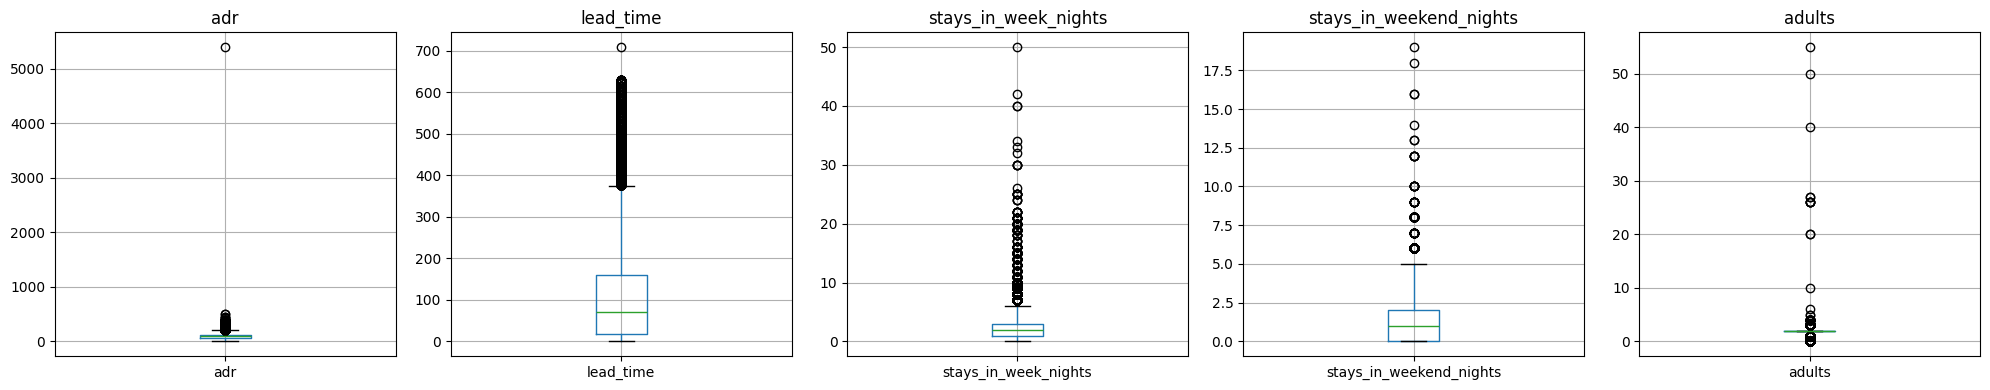

In [148]:
import matplotlib.pyplot as plt

cols_to_plot = [
    "adr",
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults"
]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(20, 4))

for ax, col in zip(axes, cols_to_plot):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

###3.3 — Detección de outliers mediante percentiles

In [149]:
import numpy as np

cols_outliers = [
    "adr",
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults"
]

outlier_limits = {}

for col in cols_outliers:
    p99 = df[col].quantile(0.99)
    p999 = df[col].quantile(0.999)

    outlier_limits[col] = {
        "p99": p99,
        "p999": p999
    }

    print(f"\n{col}")
    print(f"P99: {p99}")
    print(f"P99.9: {p999}")


adr
P99: 252.0
P99.9: 326.40429000000336

lead_time
P99: 444.0
P99.9: 605.0

stays_in_week_nights
P99: 10.0
P99.9: 19.0

stays_in_weekend_nights
P99: 4.0
P99.9: 6.0

adults
P99: 3.0
P99.9: 3.0


###3.4 — Tratamiento de outliers en ADR basado en percentiles

Se aplica un tratamiento de outliers en la variable `adr` utilizando percentiles extremos (P1 y P99).

Este enfoque permite eliminar únicamente los valores más extremos de la distribución, evitando la pérdida de información relevante del negocio.

A diferencia de métodos más agresivos, este criterio:

* Mantiene la estructura general del mercado hotelero
* Conserva reservas de alto valor económico
* Reduce el impacto de valores claramente anómalos

In [150]:
# Definimos percentiles extremos
p1 = df["adr"].quantile(0.01)
p99 = df["adr"].quantile(0.99)

print(f"Límite inferior (P1): {p1}")
print(f"Límite superior (P99): {p99}")

# Filtrado de outliers extremos
df = df[(df["adr"] >= p1) & (df["adr"] <= p99)]

print(f"Shape tras tratamiento de outliers en ADR: {df.shape}")

Límite inferior (P1): 1.926000000000022
Límite superior (P99): 252.0
Shape tras tratamiento de outliers en ADR: (116210, 27)


###3.5 — Justificación del uso de percentiles frente a IQR

El método IQR, aunque ampliamente utilizado en estadística clásica, presenta limitaciones en este contexto:

No considera el significado económico de los datos
Puede eliminar observaciones válidas de alto valor (hoteles premium, temporadas altas)
Asume distribuciones simétricas, lo cual no se cumple en variables de precios turísticos

Por el contrario, el enfoque basado en percentiles:

* Permite conservar la estructura real del mercado
* Es más robusto frente a distribuciones asimétricas
* Se adapta mejor a problemas de revenue management

Por estas razones, se prioriza un enfoque conservador que mantiene la integridad del dataset sin eliminar información potencialmente relevante para el modelado.

###3.6 — Verificación del tratamiento de outliers en ADR

En esta sección se valida el resultado del tratamiento de outliers aplicado a la variable adr.

Para evitar inconsistencias metodológicas, la verificación se realiza utilizando los límites originales definidos antes del filtrado (percentiles P1 y P99 calculados en la fase de análisis).

Se comprueba:

* La distribución estadística de la variable tras la limpieza
* El rango mínimo y máximo actual
* La existencia de posibles valores fuera del rango definido inicialmente

Este enfoque garantiza una validación coherente del proceso de limpieza, evitando errores derivados del recalculo dinámico de percentiles sobre el dataset ya filtrado.

In [151]:
# Límites usados originalmente en el tratamiento
p1 = 1.926
p99 = 252.0

# Resumen estadístico tras el filtrado
print("Resumen tras tratamiento de outliers en ADR:\n")
print(df["adr"].describe())

# Verificación de rangos reales del dataset
print("\nRango real de ADR:")
print("Min:", df["adr"].min())
print("Max:", df["adr"].max())

# Comprobación de que todos los valores están dentro del rango definido inicialmente
out_of_range = df[(df["adr"] < p1) | (df["adr"] > p99)]

print("\nNúmero de valores fuera del rango permitido:")
print(out_of_range.shape[0])

Resumen tras tratamiento de outliers en ADR:

count    116210.000000
mean        101.688476
std          43.079469
min           2.000000
25%          70.000000
50%          95.000000
75%         125.100000
max         252.000000
Name: adr, dtype: float64

Rango real de ADR:
Min: 2.0
Max: 252.0

Número de valores fuera del rango permitido:
0


###3.7 — Conclusión del tratamiento de valores anómalos

El tratamiento de outliers se ha aplicado exclusivamente sobre la variable ADR debido a su impacto directo en la estimación de ingresos y su sensibilidad a valores inconsistentes.
El resto de variables numéricas presentan valores extremos, pero estos reflejan comportamiento real del negocio hotelero y no errores de registro, por lo que se mantienen sin modificación para preservar la información del dataset.

##**4.0 — Análisis de correlación**

El objetivo de esta sección es analizar las relaciones entre las variables numéricas del dataset mediante una matriz de correlación.

Este análisis permite identificar:

* Relaciones entre variables predictoras
* Posibles problemas de multicolinealidad
* Variables más relacionadas con los objetivos del modelo, especialmente la cancelación de reservas y el precio medio

Se utilizará la correlación de Pearson como medida principal, ya que permite evaluar relaciones lineales entre variables numéricas.










####4.1 — Matríz de correlación

La matriz de correlación permite analizar las relaciones lineales entre las variables numéricas del dataset con el objetivo de identificar patrones de dependencia, posibles redundancias y relaciones relevantes con las variables objetivo.

En términos generales, se observa que la mayoría de las variables presentan correlaciones bajas o moderadas entre sí, lo que indica que no existe un problema significativo de multicolinealidad. Este resultado es positivo, ya que sugiere que las variables aportan información complementaria y no redundante.

En relación con la variable objetivo `is_canceled`, se identifican correlaciones leves pero coherentes con el comportamiento del negocio. Destaca especialmente la relación positiva con `lead_time`, lo que indica que las reservas realizadas con mayor antelación tienden a presentar una mayor probabilidad de cancelación. Por otro lado, variables como el `número de solicitudes especiales` o la `necesidad de plaza de aparcamiento` muestran una relación negativa, sugiriendo menor propensión a cancelar en estos casos.

Respecto a la variable `adr`, se observan correlaciones moderadas con variables relacionadas con el tamaño del grupo y el tipo de estancia, lo que indica que el precio medio está influenciado principalmente por características estructurales de la reserva más que por el comportamiento del cliente.

En cuanto a las variables de estancia, se aprecia una relación lógica entre las noches entre semana y fin de semana, así como una ligera correlación entre el número de adultos y niños, reflejando patrones habituales en reservas familiares o de grupos.

En conjunto, el análisis sugiere que el dataset no presenta problemas graves de redundancia entre variables y que la información está distribuida de forma equilibrada, lo que lo hace adecuado para tareas de modelado predictivo.

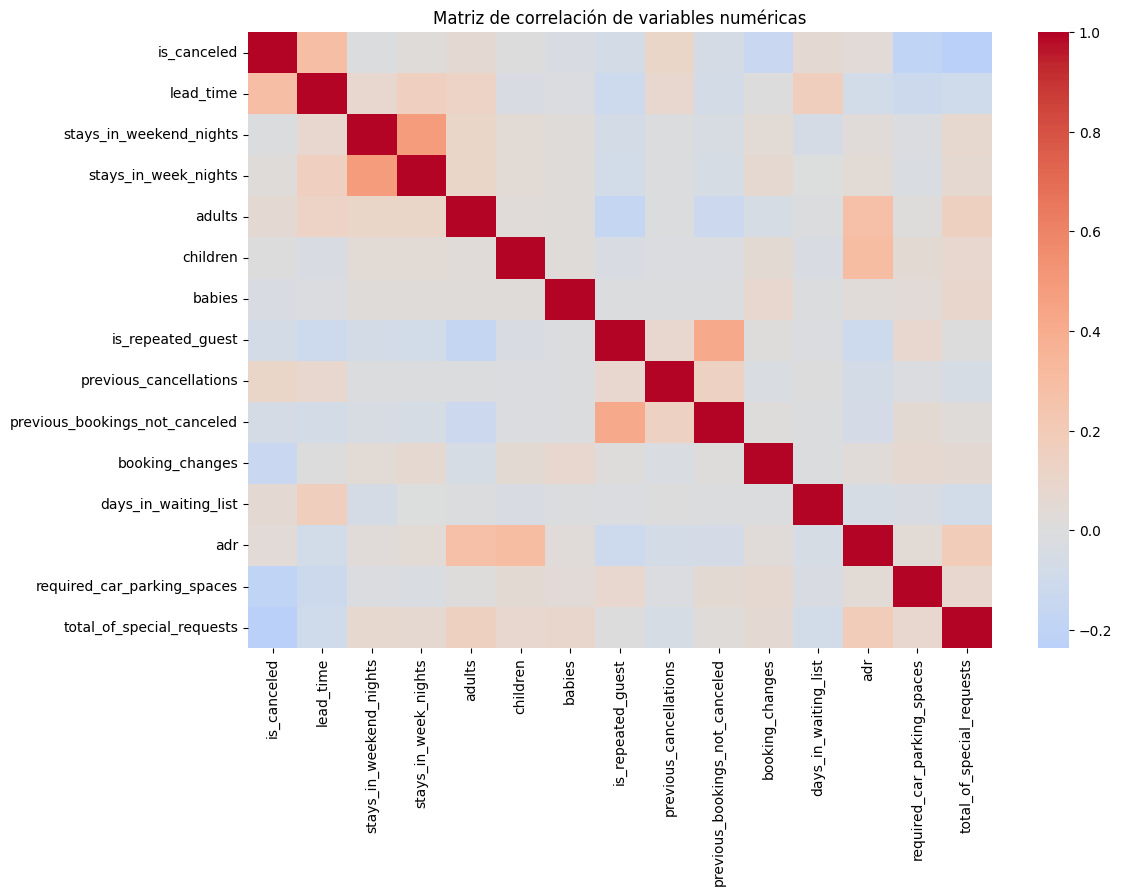

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selección de variables numéricas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Matriz de correlación
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

####4.2 — Correlación con variables objetivo

El análisis de correlación con las variables objetivo permite identificar qué características del dataset presentan mayor relación con la cancelación de reservas y con el precio medio diario.

En el caso de `is_canceled`, la variable con mayor correlación positiva es `lead_time` (0.29), lo que indica que las reservas realizadas con mayor antelación presentan una mayor tendencia a cancelarse. También destacan, aunque con menor intensidad, las variables `previous_cancellations` y `days_in_waiting_list`, sugiriendo que ciertos patrones históricos de comportamiento influyen en la cancelación.

Por el contrario, las correlaciones negativas más relevantes se observan en `total_of_special_requests` (-0.24), `required_car_parking_spaces` (-0.20) y `booking_changes` (-0.14). Esto sugiere que los clientes más comprometidos con la reserva por ejemplo, aquellos que solicitan servicios adicionales o realizan modificaciones tienden a cancelar menos.
Respecto a `adr`, las variables con mayor correlación positiva son `children` (0.30), `adults` (0.28) y `total_of_special_requests` (0.19). Esto indica que las reservas de grupos familiares o clientes con mayores necesidades tienden a asociarse con tarifas más elevadas.
También se observa una correlación negativa moderada entre ADR y variables como `is_repeated_guest` o `lead_time`, lo que podría indicar que clientes recurrentes o reservas realizadas con mucha antelación acceden a precios más bajos.

En términos generales, las correlaciones obtenidas son moderadas o bajas, lo cual es habitual en problemas reales de predicción hotelera. Esto sugiere que el comportamiento de cancelación y el precio de las reservas dependen de la combinación de múltiples variables más que de una única característica dominante.

In [153]:
target_cols = ["is_canceled", "adr"]

corr_target = df[num_cols].corr()[target_cols].sort_values(by="is_canceled", ascending=False)

corr_target

,is_canceled,adr
is_canceled,1.000000,0.034792
lead_time,0.291347,-0.085471
previous_cancellations,0.111178,-0.073497
adults,0.057715,0.279524
days_in_waiting_list,0.054498,-0.045931
adr,0.034792,1.000000
stays_in_week_nights,0.017886,0.043026
children,0.001870,0.304164
stays_in_weekend_nights,-0.008171,0.030270
babies,-0.031883,0.030809


####4.3 — Verificación de multicolinealidad

Aunque la matriz de correlación no muestra relaciones extremadamente altas entre variables numéricas, se realiza una validación adicional mediante el cálculo del Variance Inflation Factor (VIF).

El VIF permite cuantificar el nivel de redundancia existente entre variables predictoras:

* Valores cercanos a 1 indican baja colinealidad
* Valores superiores a 5 sugieren correlación moderada
* Valores superiores a 10 indican posible multicolinealidad severa

Este análisis permite confirmar que el dataset es adecuado para fases posteriores de modelado

In [154]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Variables numéricas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Excluir targets
vif_features = num_cols.drop(["is_canceled", "adr"])

# Crear dataframe para VIF
X = df[vif_features]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data.sort_values(by="VIF", ascending=False)

,Variable,VIF
3,adults,4.108525
2,stays_in_week_nights,3.649236
1,stays_in_weekend_nights,2.492201
0,lead_time,2.171945
12,total_of_special_requests,1.627728
6,is_repeated_guest,1.247526
8,previous_bookings_not_canceled,1.242717
9,booking_changes,1.132798
11,required_car_parking_spaces,1.096379
4,children,1.078463


Las variables con mayor VIF son `adults` (4.11), `stays_in_week_nights` (3.65) y `stays_in_weekend_nights` (2.49), aunque sus valores se mantienen por debajo de los umbrales comúnmente asociados a problemas graves de redundancia (VIF > 5 o VIF > 10).

El resto de variables presentan valores cercanos a 1, indicando una baja dependencia lineal entre características.

En conjunto, el análisis confirma que el dataset mantiene una estructura adecuada para tareas de modelado predictivo y que no es necesario eliminar variables por problemas de multicolinealidad en esta fase del proyecto.

## **5.0 — Feature Engineering**

En esta sección se realiza el proceso de `feature engineering` con el objetivo de generar nuevas variables que permitan representar de forma más precisa el comportamiento de las reservas hoteleras.

### 5.1 — Creación de variables derivadas de huéspedes

Se generan nuevas variables relacionadas con la composición de los huéspedes para representar de forma más completa el tamaño y características de cada reserva.

Estas variables permiten simplificar información dispersa en múltiples columnas y facilitan la identificación de patrones asociados a reservas familiares, grupos o estancias individuales.

In [155]:
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

df["has_children"] = (
    (df["children"] + df["babies"]) > 0
).astype(int)

df[[
    "adults",
    "children",
    "babies",
    "total_guests",
    "has_children"
]].head()

,adults,children,babies,total_guests,has_children
2,1,0.0,0,1.0,0
75559,1,0.0,0,1.0,0
75560,2,0.0,0,2.0,0
75561,2,0.0,0,2.0,0
75562,2,0.0,0,2.0,0


###5.2 — Creación de variables derivadas de la estancia

Se construyen variables relacionadas con la duración total de la estancia a partir de las noches entre semana y fin de semana.

Estas variables permiten representar de forma más precisa el comportamiento de permanencia de los clientes y pueden resultar especialmente relevantes para modelos de ocupación, cancelación y estimación de ingresos.

In [156]:
df["total_nights"] = (
    df["stays_in_week_nights"] +
    df["stays_in_weekend_nights"]
)

df["is_long_stay"] = (
    df["total_nights"] >= 7
).astype(int)

df[[
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "total_nights",
    "is_long_stay"
]].head()

,stays_in_week_nights,stays_in_weekend_nights,total_nights,is_long_stay
2,1,0,1,0
75559,2,0,2,0
75560,2,0,2,0
75561,2,0,2,0
75562,2,0,2,0


###5.3 — Extracción de variables temporales

A partir de la variable unificada `arrival_date`, se extraen nuevos componentes temporales que permiten capturar patrones estacionales y tendencias de comportamiento a lo largo del tiempo.

Estas variables facilitarán posteriormente el análisis de demanda hotelera, estacionalidad y comportamiento temporal de las reservas.

In [157]:
df["arrival_year"] = df["arrival_date"].dt.year
df["arrival_month"] = df["arrival_date"].dt.month
df["arrival_dayofweek"] = df["arrival_date"].dt.dayofweek

df[[
    "arrival_date",
    "arrival_year",
    "arrival_month",
    "arrival_dayofweek"
]].head()

,arrival_date,arrival_year,arrival_month,arrival_dayofweek
2,2015-07-01,2015,7,2
75559,2015-07-01,2015,7,2
75560,2015-07-01,2015,7,2
75561,2015-07-01,2015,7,2
75562,2015-07-01,2015,7,2


###5.4 — Generación de variables de estacionalidad

Se crean variables categóricas relacionadas con la estación del año para representar de forma más interpretable los ciclos temporales del negocio hotelero.

La estacionalidad es uno de los factores más relevantes dentro del Revenue Management, ya que influye directamente sobre la demanda, precios, ocupación y cancelaciones.

In [158]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["arrival_month"].apply(get_season)

df[[
    "arrival_month",
    "season"
]].head()

,arrival_month,season
2,7,Summer
75559,7,Summer
75560,7,Summer
75561,7,Summer
75562,7,Summer


###5.5 — Creación de variables de negocio

Se generan variables derivadas orientadas específicamente al contexto operativo hotelero y al análisis de Revenue Management.

Estas variables buscan representar patrones de comportamiento más complejos, como reservas familiares, duración media por huésped o estancias prolongadas, aportando información de alto valor para futuros modelos predictivos.

In [159]:
df["nights_per_guest"] = (
    df["total_nights"] / df["total_guests"]
)

df[[
    "total_nights",
    "total_guests",
    "nights_per_guest"
]].head()

,total_nights,total_guests,nights_per_guest
2,1,1.0,1.0
75559,2,1.0,2.0
75560,2,2.0,1.0
75561,2,2.0,1.0
75562,2,2.0,1.0


## **6.0 — Enriquecimiento de datos**

En esta sección se incorporan fuentes de datos externas con el objetivo de enriquecer el dataset original y aportar contexto adicional al análisis.

Dado que el dataset de reservas hoteleras no incluye información geográfica, las variables externas se integran como proxies del entorno turístico general (Canarias), permitiendo capturar efectos relacionados con la demanda, estacionalidad y comportamiento del mercado.

Antes de realizar la integración, se lleva a cabo un proceso de exploración, limpieza y análisis de cada fuente externa para garantizar su calidad, coherencia y utilidad dentro del modelo.

### 6.1 — Preparación de datos externos (Total ocupacion de turistas)

Se utiliza un dataset procedente del Instituto Canario de Estadística (ISTAC), que proporciona información agregada sobre la actividad turística en Canarias.

Este conjunto de datos permite incorporar variables relacionadas con la demanda turística, ocupación y estacionalidad real del destino, aportando un contexto macroeconómico de gran valor para el análisis de reservas.

Antes de su integración, se realiza un proceso de exploración y limpieza para comprender su estructura, calidad y nivel de agregación.

#### 6.1.1 — Carga de datos y visualización de primeras columnas

Se carga el dataset de actividad hotelera procedente de ISTAC.

Este dataset no está en un formato tabular estándar, sino que contiene:
- Metadatos en las primeras filas
- Estructura tipo informe (no analítica)
- Columnas no etiquetadas correctamente

Por tanto, será necesario un proceso de reconstrucción antes de su uso.

In [160]:
import pandas as pd

url = "https://raw.githubusercontent.com/Mriano29/hotel_demand_forecasting_system/refs/heads/main/data/raw_data/total_tourist_accomodations.csv"

df_tourist_accomodations = pd.read_csv(url)

print(df_tourist_accomodations.shape)
df_tourist_accomodations.head()

(640, 226)


,"Establecimientos abiertos, plazas y habitaciones ofertadas, tasas de ocupación, tarifa media, ingresos y empleos. Islas y municipios de Canarias por periodos",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 216,Unnamed: 217,Unnamed: 218,Unnamed: 219,Unnamed: 220,Unnamed: 221,Unnamed: 222,Unnamed: 223,Unnamed: 224,Unnamed: 225
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last update,"Apr 22, 2026",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Units:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Measure unit (Tarifa media diaria): Euro (Units),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Measure unit (Empleos): Number (Units),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 6.1.2 — Inspección inicial de la estructura

Se inspeccionan las primeras filas del dataset para identificar:

- Presencia de metadatos
- Ubicación de la cabecera real
- Posible inicio de los datos

In [161]:
for i in range(25):
    print(f"\n--- FILA {i} ---")
    print(df_tourist_accomodations.iloc[i].values[:10])


--- FILA 0 ---
[nan nan nan nan nan nan nan nan nan nan]

--- FILA 1 ---
['Last update' 'Apr 22, 2026' nan nan nan nan nan nan nan nan]

--- FILA 2 ---
['Units:' nan nan nan nan nan nan nan nan nan]

--- FILA 3 ---
[nan 'Measure unit (Tarifa media diaria): Euro (Units)' nan nan nan nan
 nan nan nan nan]

--- FILA 4 ---
[nan 'Measure unit (Empleos): Number (Units)' nan nan nan nan nan nan nan
 nan]

--- FILA 5 ---
[nan
 'Measure unit (Empleos por cada 100 viajeros entrados): Percentage (Units)'
 nan nan nan nan nan nan nan nan]

--- FILA 6 ---
[nan
 'Measure unit (Empleos por cada 10.000 euros de ingresos): Por cada 10.000 (Unidades)'
 nan nan nan nan nan nan nan nan]

--- FILA 7 ---
[nan
 'Measure unit (Empleos por cada 1.000 pernoctaciones): Per each 1.000 (Units)'
 nan nan nan nan nan nan nan nan]

--- FILA 8 ---
[nan
 'Measure unit (Empleos por cada 100 plazas alojativas): Percentage (Units)'
 nan nan nan nan nan nan nan nan]

--- FILA 9 ---
[nan 'Measure unit (Establecimientos): E

#### 6.1.3 — Identificación de la cabecera real

Tras la inspección, se identifica que:

- La fila 20 contiene los periodos temporales (fechas)
- Las filas anteriores contienen metadatos (unidades, descripción, etc.)

Por tanto, la fila 20 se utilizará como referencia para reconstruir las columnas del dataset.

In [162]:
header_row = 20
df_tourist_accomodations.iloc[header_row].values[:10]

array([nan, nan, '03/2026', '02/2026', '01/2026', '2025', '12/2025',
       '11/2025', '10/2025', '09/2025'], dtype=object)

#### 6.1.4 — Extracción de columnas temporales

Se extraen las columnas correspondientes a los periodos temporales a partir de la fila identificada como cabecera.

Estas columnas representan observaciones mensuales de los distintos indicadores.

In [163]:
# Extraer fechas (columnas temporales)
date_cols = df_tourist_accomodations.iloc[header_row, 2:].values

# Crear dataset a partir de los datos reales
df_clean = df_tourist_accomodations.iloc[header_row + 1:].copy()

# Asignar nombres de columnas
df_clean.columns = ['indicator', 'location'] + list(date_cols)

df_clean = df_clean.reset_index(drop=True)

df_clean.head()

,indicator,location,03/2026,02/2026,01/2026,2025,12/2025,11/2025,10/2025,09/2025,...,10/2009,09/2009,08/2009,07/2009,06/2009,05/2009,04/2009,03/2009,02/2009,01/2009
0,Tarifa media diaria,Canary Islands,"143,74","143,46","140,3","127,26","146,81","135,51","126,59","115,77",...,"55,06","52,35","57,9","53,16","50,93","51,25","59,89","57,17","56,48","56,75"
1,NaN,Lanzarote,"141,07","136,2","129,12","126,43","138,04","124,01","125,47","119,4",...,"48,88","47,09","47,83","47,19","41,88","44,71","50,27","48,09","49,73","49,75"
2,NaN,Arrecife,"110,94","112,65","115,99","108,39","115,56","100,94","99,37","114,64",...,"62,89","44,15",42,"40,93","32,98","44,21","43,12","34,9","56,07","62,41"
3,NaN,Haría,"63,65","58,81","61,9","67,46","57,76","62,12","62,44","59,06",...,"30,61","32,65","32,5","33,26","28,66","33,24","33,63","32,18","33,25","27,92"
4,NaN,Teguise,"125,17","107,53","104,77","102,03","112,83","103,6","100,45","93,88",...,"45,69","50,72","52,74","50,61","39,47","40,86","47,65","47,01","51,32","52,7"


#### 6.1.5 — Análisis de estructura tras reconstrucción

Se observa que:
- La columna `indicator` contiene valores nulos en muchas filas
- Los indicadores están organizados en bloques jerárquicos
- Cada bloque corresponde a un tipo de métrica (ADR, ocupación, etc.)

In [164]:
df_clean[['indicator', 'location']].head(20)

,indicator,location
0,Tarifa media diaria,Canary Islands
1,NaN,Lanzarote
2,NaN,Arrecife
3,NaN,Haría
4,NaN,Teguise
5,NaN,Tías
6,NaN,Yaiza
7,NaN,Fuerteventura
8,NaN,Antigua
9,NaN,La Oliva


#### 6.1.6 — Propagación de indicadores

Se aplica forward fill para propagar los valores de la columna `indicator`.

Esto permite asignar correctamente cada fila a su métrica correspondiente.

In [165]:
df_clean['indicator'] = df_clean['indicator'].ffill()

df_clean[['indicator', 'location']].head(20)

,indicator,location
0,Tarifa media diaria,Canary Islands
1,Tarifa media diaria,Lanzarote
2,Tarifa media diaria,Arrecife
3,Tarifa media diaria,Haría
4,Tarifa media diaria,Teguise
5,Tarifa media diaria,Tías
6,Tarifa media diaria,Yaiza
7,Tarifa media diaria,Fuerteventura
8,Tarifa media diaria,Antigua
9,Tarifa media diaria,La Oliva


#### 6.1.7 — Filtrado a Canarias

Se filtra el dataset para mantener únicamente el nivel agregado de Canarias.

Esta decisión se toma para asegurar coherencia con el dataset principal, que no contiene información geográfica.

In [166]:
df_canarias = df_clean[df_clean['location'] == 'Canary Islands'].copy()

print(df_canarias.shape)
df_canarias.head()

(13, 226)


,indicator,location,03/2026,02/2026,01/2026,2025,12/2025,11/2025,10/2025,09/2025,...,10/2009,09/2009,08/2009,07/2009,06/2009,05/2009,04/2009,03/2009,02/2009,01/2009
0,Tarifa media diaria,Canary Islands,"143,74","143,46","140,3","127,26","146,81","135,51","126,59","115,77",...,"55,06","52,35","57,9","53,16","50,93","51,25","59,89","57,17","56,48","56,75"
47,Empleos,Canary Islands,75626,75364,75575,72120,76265,73965,74070,72974,...,51000,51082,51542,50769,50115,48113,52597,53714,54478,55118
94,Empleos por cada 100 viajeros entrados,Canary Islands,"6,08","6,51","6,67","6,06","6,64","6,32","5,83","6,46",...,"5,62","6,44","4,72","5,17","6,58","6,59","6,1","6,03","6,72","6,55"
141,Empleos por cada 10.000 euros de ingresos,Canary Islands,"1,26","1,34","1,29","1,46","1,31","1,33","1,45","1,62",...,3,"3,21","2,48","3,02","3,74","3,6","2,96","2,57","3,02","2,47"
188,Empleos por cada 1.000 pernoctaciones,Canary Islands,"8,9","9,3","8,99","8,74","9,38","9,09","8,54","9,17",...,"7,48","7,9","5,85","6,55","8,64","8,97","8,03","6,98","7,86",7


#### 6.1.8 — Validación final de estructura

Se valida que el dataset contiene:

- Un único nivel geográfico (Canarias)
- Indicadores correctamente propagados
- Variables temporales en formato ancho

A partir de este punto, el dataset está listo para transformación a formato longitudinal.

In [167]:
df_canarias['indicator'].value_counts()

,count
indicator,
Tarifa media diaria,1
Empleos,1
Empleos por cada 100 viajeros entrados,1
Empleos por cada 10.000 euros de ingresos,1
Empleos por cada 1.000 pernoctaciones,1
Empleos por cada 100 plazas alojativas,1
Establecimientos,1
Habitaciones,1
Ingresos totales,1


#### 6.1.9 — Transformación a formato longitudinal (MELT)

El dataset se encuentra actualmente en formato ancho (wide format), donde cada columna representa un periodo temporal.

Para su uso en modelos de machine learning y posterior integración con el dataset principal, es necesario transformarlo a formato longitudinal (long format).

Este formato permite:

- Representar cada observación como una combinación de indicador y fecha
- Facilitar el análisis temporal
- Simplificar la integración con otros datasets

Se utiliza la operación `melt` para realizar esta transformación.

##### 6.1.9.1 — Identificación de columnas temporales

Se identifican las columnas que representan periodos temporales.

Estas columnas serán utilizadas como variables de medida en la transformación.

In [168]:
# Separar columnas no temporales
id_vars = ['indicator', 'location']

# Columnas temporales (todas las demás)
value_vars = [col for col in df_canarias.columns if col not in id_vars]

len(value_vars), value_vars[:5]

(224, ['03/2026', '02/2026', '01/2026', '2025', '12/2025'])

##### 6.1.9.2 — Aplicación de MELT

Se aplica la transformación de formato ancho a formato largo.

Cada fila representará un valor de un indicador en un momento temporal específico.

In [169]:
df_ta_long = df_canarias.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='date',
    value_name='value'
)

df_ta_long.head()

,indicator,location,date,value
0,Tarifa media diaria,Canary Islands,03/2026,"143,74"
1,Empleos,Canary Islands,03/2026,75626
2,Empleos por cada 100 viajeros entrados,Canary Islands,03/2026,"6,08"
3,Empleos por cada 10.000 euros de ingresos,Canary Islands,03/2026,"1,26"
4,Empleos por cada 1.000 pernoctaciones,Canary Islands,03/2026,"8,9"


##### 6.1.9.3 — Conversión de tipos de datos

Se convierten las variables a tipos adecuados:

- `date` → formato temporal
- `value` → numérico (float)

Esto es necesario para el análisis y modelado posterior.

In [170]:
# Filtrar solo fechas con formato mensual (contienen "/")
df_ta_long = df_ta_long[df_ta_long['date'].astype(str).str.contains('/')].copy()

# Convertir fechas de forma segura
df_ta_long['date'] = pd.to_datetime(df_ta_long['date'], format='%m/%Y', errors='coerce')

# Convertir valores numéricos (coma → punto)
df_ta_long['value'] = (
    df_ta_long['value']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_ta_long['value'] = pd.to_numeric(df_ta_long['value'], errors='coerce')

df_ta_long.dtypes

,0
indicator,object
location,object
date,datetime64[ns]
value,float64


##### 6.1.9.4 — Validación de datos nulos

Se revisan valores nulos tras la transformación.

Los nulos pueden deberse a:

- Periodos sin datos disponibles
- Indicadores no aplicables en ciertos periodos
- Errores de conversión

In [171]:
df_ta_long.isnull().sum().sort_values(ascending=False)

,0
indicator,0
location,0
date,0
value,0


##### 6.1.9.5 — Validación estructural final

Se valida que el dataset cumple con:

- Estructura longitudinal correcta
- Tipos de datos adecuados
- Preparación para análisis temporal y modelado

Este dataset será utilizado posteriormente para la agregación de variables y su integración con el dataset principal de cancelaciones.

In [172]:
df_ta_long.head()

,indicator,location,date,value
0,Tarifa media diaria,Canary Islands,2026-03-01,143.74
1,Empleos,Canary Islands,2026-03-01,75626.00
2,Empleos por cada 100 viajeros entrados,Canary Islands,2026-03-01,6.08
3,Empleos por cada 10.000 euros de ingresos,Canary Islands,2026-03-01,1.26
4,Empleos por cada 1.000 pernoctaciones,Canary Islands,2026-03-01,8.90


In [173]:
df_ta_long.info()

df_ta_long['indicator'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 2691 entries, 0 to 2911
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   indicator  2691 non-null   object        
 1   location   2691 non-null   object        
 2   date       2691 non-null   datetime64[ns]
 3   value      2691 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 105.1+ KB


,count
indicator,
Tarifa media diaria,207
Empleos,207
Empleos por cada 100 viajeros entrados,207
Empleos por cada 10.000 euros de ingresos,207
Empleos por cada 1.000 pernoctaciones,207
Empleos por cada 100 plazas alojativas,207
Establecimientos,207
Habitaciones,207
Ingresos totales,207


##### 6.1.9.6 — Transformación a formato ancho


Tras la transformación a formato longitudinal, se procede a convertir el dataset a formato ancho (wide format) mediante una operación de pivot.

El objetivo es:

- Representar cada indicador como una variable (feature)
- Obtener una fila por periodo temporal
- Preparar el dataset para su uso en modelos de machine learning

Este paso es crítico para transformar los datos en una estructura adecuada para modelado.

In [174]:
df_ta_wide = df_ta_long.pivot_table(
    index='date',
    columns='indicator',
    values='value'
)

df_ta_wide.head()

indicator,Empleos,Empleos por cada 1.000 pernoctaciones,Empleos por cada 10.000 euros de ingresos,Empleos por cada 100 plazas alojativas,Empleos por cada 100 viajeros entrados,Establecimientos,Habitaciones,Ingresos por habitación,Ingresos totales,Plazas,Tarifa media diaria,Tasa de ocupación por habitación,Tasa de ocupación por plaza
date,,,,,,,,,,,,,
2009-01-01,55118.0,7.00,2.47,12.60,6.55,1872.0,177298.0,40.57,222801853.4,437453.0,56.75,71.50,58.04
2009-02-01,54478.0,7.86,3.02,12.52,6.72,1862.0,176299.0,36.51,180092848.9,435138.0,56.48,64.67,56.89
2009-03-01,53714.0,6.98,2.57,12.30,6.03,1862.0,176600.0,38.16,208754329.9,436734.0,57.17,66.76,56.86
2009-04-01,52597.0,8.03,2.96,12.10,6.10,1846.0,175818.0,33.75,177880065.3,434769.0,59.89,56.37,50.24
2009-05-01,48113.0,8.97,3.60,11.32,6.59,1798.0,172152.0,25.04,133522737.5,424943.0,51.25,48.87,40.71


##### 6.1.9.7 — Limpieza de nombres de columnas

Se normalizan los nombres de columnas eliminando:

- espacios
- mayúsculas
- acentos

Esto mejora la compatibilidad del dataset con herramientas de machine learning y pipelines de producción.

In [175]:
import unicodedata

def clean_column(col):
    col = col.strip().lower().replace(' ', '_')
    col = ''.join(
        c for c in unicodedata.normalize('NFD', col)
        if unicodedata.category(c) != 'Mn'
    )
    return col

df_ta_wide.columns = [clean_column(col) for col in df_ta_wide.columns]

df_ta_wide.columns = df_ta_wide.columns.str.replace('.', '_', regex=False)

df_ta_wide.head()

,empleos,empleos_por_cada_1_000_pernoctaciones,empleos_por_cada_10_000_euros_de_ingresos,empleos_por_cada_100_plazas_alojativas,empleos_por_cada_100_viajeros_entrados,establecimientos,habitaciones,ingresos_por_habitacion,ingresos_totales,plazas,tarifa_media_diaria,tasa_de_ocupacion_por_habitacion,tasa_de_ocupacion_por_plaza
date,,,,,,,,,,,,,
2009-01-01,55118.0,7.00,2.47,12.60,6.55,1872.0,177298.0,40.57,222801853.4,437453.0,56.75,71.50,58.04
2009-02-01,54478.0,7.86,3.02,12.52,6.72,1862.0,176299.0,36.51,180092848.9,435138.0,56.48,64.67,56.89
2009-03-01,53714.0,6.98,2.57,12.30,6.03,1862.0,176600.0,38.16,208754329.9,436734.0,57.17,66.76,56.86
2009-04-01,52597.0,8.03,2.96,12.10,6.10,1846.0,175818.0,33.75,177880065.3,434769.0,59.89,56.37,50.24
2009-05-01,48113.0,8.97,3.60,11.32,6.59,1798.0,172152.0,25.04,133522737.5,424943.0,51.25,48.87,40.71


##### 6.1.9.8 — Validación final

Se comprueba:

- Número de filas (periodos temporales)
- Número de variables (indicadores)
- Tipos de datos

In [176]:
df_ta_wide.shape
df_ta_wide.dtypes

,0
empleos,float64
empleos_por_cada_1_000_pernoctaciones,float64
empleos_por_cada_10_000_euros_de_ingresos,float64
empleos_por_cada_100_plazas_alojativas,float64
empleos_por_cada_100_viajeros_entrados,float64
establecimientos,float64
habitaciones,float64
ingresos_por_habitacion,float64
ingresos_totales,float64
plazas,float64


#### 6.1.10 — Integración del dataset

##### 6.1.10.1 — Creación de variable temporal mensual en reservas

Se crea una variable `date` a partir de `arrival_date`, convirtiéndola al inicio de cada mes mediante la transformación a periodo mensual (`to_period("M")`) y su posterior conversión a timestamp.

Este paso permite homogeneizar la granularidad temporal del dataset de reservas con el dataset de indicadores turísticos, que está agregado a nivel mensual.


In [177]:
df["date"] = df["arrival_date"].dt.to_period("M").dt.to_timestamp()

##### 6.1.10.2 — Preparación del dataset de ocupación turistica

Se reinicia el índice del dataset de indicadores (`df_ta_wide`) para convertir la columna de fechas en una variable accesible como columna estándar.

Posteriormente, se asegura que la variable `date` tenga formato datetime, garantizando la compatibilidad con el dataset de reservas durante el proceso de unión.


In [178]:
df_ta_wide = df_ta_wide.reset_index()
df_ta_wide["date"] = pd.to_datetime(df_ta_wide["date"])

##### 6.1.10.3 — Preparación del lag en dataset del ISTAC

Se aplica un desplazamiento temporal de un mes hacia adelante en la variable `date` del dataset de indicadores turísticos.

Este ajuste (lag) permite que cada observación de reservas se asocie con información del mes anterior, evitando el uso de datos del mismo periodo en el que ocurre la reserva.


In [179]:
df_ta_wide["date"] = df_ta_wide["date"] + pd.offsets.MonthBegin(1)

##### 6.1.10.4 — Merge de los datasets

Se realiza la unión entre el dataset de reservas y el dataset de indicadores turísticos utilizando la variable común `date`.

El tipo de unión utilizado es un **left join**, lo que garantiza que todas las reservas se conserven y únicamente se añada la información de indicadores cuando exista correspondencia temporal.


In [180]:
df_hb_ta = df.merge(
    df_ta_wide,
    on="date",
    how="left"
)

df_hb_ta.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,empleos_por_cada_100_plazas_alojativas,empleos_por_cada_100_viajeros_entrados,establecimientos,habitaciones,ingresos_por_habitacion,ingresos_totales,plazas,tarifa_media_diaria,tasa_de_ocupacion_por_habitacion,tasa_de_ocupacion_por_plaza
0,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
1,City Hotel,0,257,0,2,1,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
2,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
3,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
4,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9


#### 6.1.11 — Validación final de la unión

In [181]:
print("Dimensiones del dataset:", df_hb_ta.shape)

print("\nRango de fechas:")
print("Min:", df_hb_ta["date"].min())
print("Max:", df_hb_ta["date"].max())

print("\nTipos de datos:")
print(df_hb_ta.dtypes.head(10))

print("\nValores nulos en variables de indicadores:")
print(
    df_hb_ta[
        [
            "empleos",
            "ingresos_totales",
            "tarifa_media_diaria",
            "tasa_de_ocupacion_por_habitacion"
        ]
    ].isnull().sum()
)

print("\nValores únicos de date (primeros 5):")
print(df_hb_ta["date"].drop_duplicates().sort_values().head())

print("\nMuestra del dataset:")
df_hb_ta.head()

Dimensiones del dataset: (116210, 50)

Rango de fechas:
Min: 2015-07-01 00:00:00
Max: 2017-08-01 00:00:00

Tipos de datos:
hotel                      category
is_canceled                   int64
lead_time                     int64
stays_in_weekend_nights       int64
stays_in_week_nights          int64
adults                        int64
children                    float64
babies                        int64
meal                       category
country                    category
dtype: object

Valores nulos en variables de indicadores:
empleos                             0
ingresos_totales                    0
tarifa_media_diaria                 0
tasa_de_ocupacion_por_habitacion    0
dtype: int64

Valores únicos de date (primeros 5):
0       2015-07-01
2712    2015-08-01
6479    2015-09-01
11488   2015-10-01
16310   2015-11-01
Name: date, dtype: datetime64[ns]

Muestra del dataset:


,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,empleos_por_cada_100_plazas_alojativas,empleos_por_cada_100_viajeros_entrados,establecimientos,habitaciones,ingresos_por_habitacion,ingresos_totales,plazas,tarifa_media_diaria,tasa_de_ocupacion_por_habitacion,tasa_de_ocupacion_por_plaza
0,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
1,City Hotel,0,257,0,2,1,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
2,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
3,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9
4,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,13.37,5.81,1746.0,167738.0,42.49,213641489.9,412368.0,62.74,67.73,58.9


### 6.2 — Preparación de datos externos (Ocupación por nacionalidad por hoteles)

El dataset obtenido del ISTAC presenta una estructura no tabular estándar, muy similar a la observada en el primer dataset analizado anteriormente.

En concreto, incluye:
- Filas iniciales con metadatos (unidades, descripciones, actualización)
- Fechas distribuidas en columnas en lugar de filas
- Valores numéricos almacenados como texto
- Estructura jerárquica (indicador, región, país)

Dado que este formato ya ha sido tratado previamente, se seguirá el mismo enfoque de limpieza:
1. Eliminación de filas irrelevantes
2. Asignación de cabeceras
3. Transformación a formato largo (long format)
4. Conversión de tipos de datos
5. Reestructuración final para análisis y posterior integración

#### 6.2.1 — Carga de datos y visualización de primeras columnas

In [182]:
url = "https://raw.githubusercontent.com/Mriano29/hotel_demand_forecasting_system/refs/heads/main/data/raw_data/occupation_by_nationality_hotels.csv"

df_occupation_hotel = pd.read_csv(url)

print(df_occupation_hotel.shape)
df_occupation_hotel.head()

(2540, 227)


,"Pernoctaciones, viajeros alojados, viajeros entrados y estancia media en hoteles según principales nacionalidades. Islas y municipios de Canarias por periodos",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 217,Unnamed: 218,Unnamed: 219,Unnamed: 220,Unnamed: 221,Unnamed: 222,Unnamed: 223,Unnamed: 224,Unnamed: 225,Unnamed: 226
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last update,"Apr 22, 2026",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Units:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Measure unit (Estancia media): Nights (Units),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Measure unit (Pernoctaciones): Nights (Units),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 6.2.2 — Inspección inicial de la estructura

In [183]:
for i in range(15):
    print(f"\n--- FILA {i} ---")
    print(df_occupation_hotel.iloc[i].values[:10])


--- FILA 0 ---
[nan nan nan nan nan nan nan nan nan nan]

--- FILA 1 ---
['Last update' 'Apr 22, 2026' nan nan nan nan nan nan nan nan]

--- FILA 2 ---
['Units:' nan nan nan nan nan nan nan nan nan]

--- FILA 3 ---
[nan 'Measure unit (Estancia media): Nights (Units)' nan nan nan nan nan
 nan nan nan]

--- FILA 4 ---
[nan 'Measure unit (Pernoctaciones): Nights (Units)' nan nan nan nan nan
 nan nan nan]

--- FILA 5 ---
[nan 'Measure unit (Viajeros alojados): Persons (Units)' nan nan nan nan
 nan nan nan nan]

--- FILA 6 ---
[nan 'Measure unit (Viajeros entrados): Persons (Units)' nan nan nan nan
 nan nan nan nan]

--- FILA 7 ---
[nan nan nan nan nan nan nan nan nan nan]

--- FILA 8 ---
['By: Tourist accommodation = Hotel' nan nan nan nan nan nan nan nan nan]

--- FILA 9 ---
[nan nan nan nan nan nan nan nan nan nan]

--- FILA 10 ---
[nan nan nan nan nan nan nan nan nan nan]

--- FILA 11 ---
[nan nan nan '03/2026' '02/2026' '01/2026' '2025' '12/2025' '11/2025'
 '10/2025']

--- FILA 12 ---

#### 6.2.3 — Asignación de cabeceras

In [184]:
header_row = 11

# Extraer fechas (columnas temporales)
date_cols = df_occupation_hotel.iloc[header_row, 3:].values

# Crear dataset a partir de los datos reales
df_clean = df_occupation_hotel.iloc[header_row + 1:].copy()

# Asignar nombres de columnas
df_clean.columns = ['indicator', 'region', 'country'] + list(date_cols)

df_clean = df_clean.reset_index(drop=True)

df_clean.head()

,indicator,region,country,03/2026,02/2026,01/2026,2025,12/2025,11/2025,10/2025,...,10/2009,09/2009,08/2009,07/2009,06/2009,05/2009,04/2009,03/2009,02/2009,01/2009
0,Estancia media,Canary Islands,Spain,"3,727934674","3,7428312","4,142758347","3,94670572","3,830239007","3,867674136","3,880565479",...,"3,952086163","5,138946821","5,577218402","4,972494328","4,296516657","4,150801742","4,094106204","4,026300668","3,992944526","4,823183267"
1,NaN,NaN,World (Spain excluded),"7,003652106","6,973487442","7,358561049","7,331070621","7,231523854","7,063721742","7,224629195",...,"8,447868717","9,536210568","9,723430827","9,884151728","9,185200423","8,621135991","8,544380964","9,013347924","8,891330556","9,923623353"
2,NaN,NaN,Germany,"7,90225274","8,36568218","8,786074965","8,568815278","8,839963379","8,273206037","8,330081189",...,"9,942361004","10,89067764","10,43125061","11,42888846","10,25437541","9,643084041","9,893489474","10,69675869","10,4902454","11,34743431"
3,NaN,NaN,Belgium,"7,706231922","7,246830239","7,782423039","7,722170614","7,928650208","7,065228557","7,542249558",...,"7,861803757","9,547286822","9,745470286","9,178040678","10,06278027","8,97","7,815826168","9,05896898","9,409010788","10,48359867"
4,NaN,NaN,Denmark,"7,504796985","7,474002923","7,314633735","7,610713369","7,81402183","7,163465325","6,774647126",...,"6,860658771","7,388794567","9,233343959","8,75722161","7,701357466","7,350251123","8,522176871","8,254505998","8,123237278","8,806297587"


#### 6.2.4 — Análisis de estructura tras reconstrucción

In [185]:
df_clean[['indicator', 'region', 'country']].head(20)

,indicator,region,country
0,Estancia media,Canary Islands,Spain
1,NaN,NaN,World (Spain excluded)
2,NaN,NaN,Germany
3,NaN,NaN,Belgium
4,NaN,NaN,Denmark
5,NaN,NaN,France
6,NaN,NaN,Ireland
7,NaN,NaN,Italy
8,NaN,NaN,Norway
9,NaN,NaN,Netherlands


#### 6.2.5 — Filtrado y preparación de datos para Canarias

In [186]:
df_clean['indicator'] = df_clean['indicator'].ffill()
df_canarias = df_clean[df_clean['region'] == 'Canary Islands'].copy()
df_canarias['indicator'].value_counts()

,count
indicator,
Estancia media,1
Pernoctaciones,1
Viajeros alojados,1
Viajeros entrados,1


#### 6.2.6 — Transformación a formato longitudinal (MELT)


##### 6.2.6.1 — Separación de columnas temporales


In [187]:
# Separar columnas no temporales
id_vars = ['indicator', 'region', 'country']

# Columnas temporales (todas las demás)
value_vars = [col for col in df_canarias.columns if col not in id_vars]

len(value_vars), value_vars[:5]

(224, ['03/2026', '02/2026', '01/2026', '2025', '12/2025'])

##### 6.2.6.2 — Aplicación de melt

In [188]:
df_oh_long = df_canarias.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='date',
    value_name='value'
)

df_oh_long.head()

,indicator,region,country,date,value
0,Estancia media,Canary Islands,Spain,03/2026,"3,727934674"
1,Pernoctaciones,Canary Islands,Spain,03/2026,522731
2,Viajeros alojados,Canary Islands,Spain,03/2026,151258
3,Viajeros entrados,Canary Islands,Spain,03/2026,140220
4,Estancia media,Canary Islands,Spain,02/2026,"3,7428312"


##### 6.2.6.3 — Conversión de formatos de fechas

In [189]:
# Filtrar solo fechas con formato mensual (contienen "/")
df_oh_long = df_oh_long[df_oh_long['date'].astype(str).str.contains('/')].copy()

# Convertir fechas de forma segura
df_oh_long['date'] = pd.to_datetime(df_oh_long['date'], format='%m/%Y', errors='coerce')

# Convertir valores numéricos (coma → punto)
df_oh_long['value'] = (
    df_oh_long['value']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_oh_long['value'] = pd.to_numeric(df_oh_long['value'], errors='coerce')

df_oh_long.dtypes

,0
indicator,object
region,object
country,object
date,datetime64[ns]
value,float64


##### 6.2.6.4 — Validación del dataset

In [190]:
print(f"\nFilas: {df_oh_long.shape[0]}")
print(f"Columnas: {df_oh_long.shape[1]}")

print("\nTIPOS DE DATOS:")
print(df_oh_long.dtypes)

print("\nVALORES NULOS:")
print(df_oh_long.isnull().sum().sort_values(ascending=False))

print("\nDUPLICADOS:")
print(df_oh_long.duplicated().sum())

print("\nCOLUMNAS:")
print(df_oh_long.columns.tolist())


Filas: 828
Columnas: 5

TIPOS DE DATOS:
indicator            object
region               object
country              object
date         datetime64[ns]
value               float64
dtype: object

VALORES NULOS:
value        4
indicator    0
region       0
country      0
date         0
dtype: int64

DUPLICADOS:
0

COLUMNAS:
['indicator', 'region', 'country', 'date', 'value']


##### 6.2.6.5 — Validación de datos nulos

Tras revisar manualmente las filas afectadas y comprobar sus fechas asociadas, se concluyó que dichos registros no formarán parte del rango temporal utilizado en el dataset final del proyecto. Por este motivo, los valores nulos se mantienen sin modificación, ya que no afectan al proceso de integración, entrenamiento ni validación del modelo.

In [191]:
df_oh_long[df_oh_long["value"].isna()]

,indicator,region,country,date,value
308,Estancia media,Canary Islands,Spain,2020-04-01,NaN
309,Pernoctaciones,Canary Islands,Spain,2020-04-01,NaN
310,Viajeros alojados,Canary Islands,Spain,2020-04-01,NaN
311,Viajeros entrados,Canary Islands,Spain,2020-04-01,NaN


##### 6.2.6.6 — Transformación a formato ancho

In [192]:
df_oh_wide = df_oh_long.pivot_table(
    index='date',
    columns='indicator',
    values='value'
)

df_oh_wide.head()

indicator,Estancia media,Pernoctaciones,Viajeros alojados,Viajeros entrados
date,,,,
2009-01-01,4.823183,563097.0,140565.0,116748.0
2009-02-01,3.992945,448787.0,123116.0,112395.0
2009-03-01,4.026301,518507.0,139405.0,128780.0
2009-04-01,4.094106,719793.0,185512.0,175812.0
2009-05-01,4.150802,704362.0,190303.0,169693.0


##### 6.2.6.7 — Limpieza de nombres de columnas

In [193]:
df_oh_wide.columns = [clean_column(col) for col in df_oh_wide.columns]

df_oh_wide.columns = df_oh_wide.columns.str.replace('.', '_', regex=False)

df_oh_wide.head()

,estancia_media,pernoctaciones,viajeros_alojados,viajeros_entrados
date,,,,
2009-01-01,4.823183,563097.0,140565.0,116748.0
2009-02-01,3.992945,448787.0,123116.0,112395.0
2009-03-01,4.026301,518507.0,139405.0,128780.0
2009-04-01,4.094106,719793.0,185512.0,175812.0
2009-05-01,4.150802,704362.0,190303.0,169693.0


#### 6.2.7 — Integración del dataset

##### 6.2.7.1 — Ajuste y normalización temporal de fechas

In [194]:
df_oh_wide = df_oh_wide.reset_index()
df_oh_wide["date"] = pd.to_datetime(df_oh_wide["date"])

# Lag temporal
df_oh_wide["date"] = df_oh_wide["date"] + pd.offsets.MonthBegin(1)


##### 6.2.7.2 — Merge con el dataset principal enriquecido

In [195]:
df_istac = df_hb_ta.merge(
    df_oh_wide,
    on="date",
    how="left"
)

df_istac.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,ingresos_por_habitacion,ingresos_totales,plazas,tarifa_media_diaria,tasa_de_ocupacion_por_habitacion,tasa_de_ocupacion_por_plaza,estancia_media,pernoctaciones,viajeros_alojados,viajeros_entrados
0,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
1,City Hotel,0,257,0,2,1,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
2,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
3,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
4,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0


##### 6.2.7.3 — Validación de la union

In [196]:
print("=" * 60)
print("ANÁLISIS GENERAL DEL DATASET ISTAC")
print("=" * 60)

# -----------------------------
# Dimensiones
# -----------------------------
print("\nDIMENSIONES")
print(f"Filas: {df_istac.shape[0]}")
print(f"Columnas: {df_istac.shape[1]}")

# -----------------------------
# Fechas
# -----------------------------
print("\nRANGO TEMPORAL")
print(f"Fecha mínima: {df_istac['date'].min()}")
print(f"Fecha máxima: {df_istac['date'].max()}")

print("\nFRECUENCIA TEMPORAL")
print(
    df_istac["date"]
    .sort_values()
    .diff()
    .value_counts()
    .head()
)

# -----------------------------
# Tipos de datos
# -----------------------------
print("\nTIPOS DE DATOS")
print(df_istac.dtypes)

# -----------------------------
# Valores nulos
# -----------------------------
print("\nVALORES NULOS")
nulls = pd.DataFrame({
    "null_count": df_istac.isnull().sum(),
    "null_percent": round(df_istac.isnull().mean() * 100, 2)
})

print(
    nulls[nulls["null_count"] > 0]
    .sort_values(by="null_count", ascending=False)
)

# -----------------------------
# Duplicados
# -----------------------------
print("\nDUPLICADOS")
print(f"Filas duplicadas: {df_istac.duplicated().sum()}")

# -----------------------------
# Estadísticas numéricas
# -----------------------------
print("\nESTADÍSTICAS NUMÉRICAS")
print(df_istac.describe())

# -----------------------------
# Cardinalidad categórica
# -----------------------------
print("\nCARDINALIDAD DE VARIABLES")
print(df_istac.nunique().sort_values(ascending=False))

# -----------------------------
# Muestra final
# -----------------------------
print("\nMUESTRA DEL DATASET")
display(df_istac.head())

ANÁLISIS GENERAL DEL DATASET ISTAC

DIMENSIONES
Filas: 116210
Columnas: 54

RANGO TEMPORAL
Fecha mínima: 2015-07-01 00:00:00
Fecha máxima: 2017-08-01 00:00:00

FRECUENCIA TEMPORAL
date
0 days     116184
31 days        15
30 days         8
29 days         1
28 days         1
Name: count, dtype: int64

TIPOS DE DATOS
hotel                                              category
is_canceled                                           int64
lead_time                                             int64
stays_in_weekend_nights                               int64
stays_in_week_nights                                  int64
adults                                                int64
children                                            float64
babies                                                int64
meal                                               category
country                                            category
market_segment                                     category
distribution_channel   

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,ingresos_por_habitacion,ingresos_totales,plazas,tarifa_media_diaria,tasa_de_ocupacion_por_habitacion,tasa_de_ocupacion_por_plaza,estancia_media,pernoctaciones,viajeros_alojados,viajeros_entrados
0,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
1,City Hotel,0,257,0,2,1,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
2,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
3,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0
4,City Hotel,0,257,0,2,2,0.0,0,HB,PRT,...,42.49,213641489.9,412368.0,62.74,67.73,58.9,4.589888,828126.0,193136.0,180424.0


### 6.3 — Preparación de datos externos (AEMET API)

En esta sección se incorpora información climática real al conjunto de datos principal con el objetivo de enriquecer el modelo de predicción turística. El clima es un factor clave en la demanda hotelera, especialmente en regiones como Canarias, donde variables como la temperatura o la precipitación influyen directamente en la estacionalidad y el comportamiento de los viajeros. Para ello, se utilizan datos históricos procedentes de AEMET, combinando varias estaciones meteorológicas representativas del archipiélago para construir una variable climática agregada más robusta.

#### 6.3.1 — Generación de bloques temporales de 6 meses

Este bloque de código divide el rango de fechas del dataset en intervalos consecutivos de 6 meses. Para ello, se obtiene la fecha mínima y máxima de la columna date y se generan automáticamente bloques temporales entre ambos límites.

Cada bloque contiene una fecha de inicio y una fecha de fin, lo que permitirá trabajar posteriormente con los datos climáticos de forma segmentada y organizada.

In [197]:
import pandas as pd
from dateutil.relativedelta import relativedelta

# Rango del dataset ISTAC
start = pd.to_datetime(df_istac["date"].min())
end = pd.to_datetime(df_istac["date"].max())

blocks = []

current = start

while current < end:
    block_end = current + relativedelta(months=6) - pd.Timedelta(days=1)

    if block_end > end:
        block_end = end

    blocks.append((
        current.strftime("%Y-%m-%d"),
        block_end.strftime("%Y-%m-%d")
    ))

    current = block_end + pd.Timedelta(days=1)

print("BLOQUES GENERADOS:")
for b in blocks:
    print(b)

BLOQUES GENERADOS:
('2015-07-01', '2015-12-31')
('2016-01-01', '2016-06-30')
('2016-07-01', '2016-12-31')
('2017-01-01', '2017-06-30')
('2017-07-01', '2017-08-01')


#### 6.3.2 — Función de petición de datos a la API

Esta celda implementa una función robusta para la extracción de datos climáticos desde la API de AEMET.

En primer lugar, se configura la autenticación mediante una API key almacenada de forma segura en Google Colab (userdata), evitando su exposición directa en el código. A continuación, se define un diccionario de estaciones meteorológicas representativas del archipiélago canario, incluyendo Tenerife Sur, Gran Canaria y Fuerteventura, con el objetivo de construir un indicador climático agregado regional.

La función `fetch_aemet` realiza la consulta a la API de AEMET para un rango temporal y una estación específica. El proceso sigue un flujo en dos pasos: una primera petición que devuelve una URL intermedia con los datos, y una segunda petición que descarga los registros reales.

Para mejorar la robustez del sistema, se incorpora un mecanismo de reintentos (retry) con un número máximo de intentos y tiempos de espera entre ellos. Esto permite manejar errores comunes en APIs externas como desconexiones de red, límites de uso (rate limiting) o fallos temporales del servidor. Además, se gestionan explícitamente errores HTTP y excepciones de conexión.

En caso de éxito, la función devuelve los datos climáticos en formato JSON. Si todos los intentos fallan, devuelve una lista vacía, permitiendo que el pipeline continúe sin interrumpirse.

In [198]:
import requests
from google.colab import userdata
import time

API_KEY = userdata.get('aemet_api')
headers = {"api_key": API_KEY}

aemet_stations = {
    "Tenerife Sur": "C429I",
    "Gran Canaria": "C649I",
    "Fuerteventura": "GCFV"
}

def fetch_aemet(start_date, end_date, station, retries=3, wait=5):

    url = (
        "https://opendata.aemet.es/opendata/api/"
        "valores/climatologicos/diarios/datos/"
        f"fechaini/{start_date}T00:00:00UTC/"
        f"fechafin/{end_date}T23:59:59UTC/"
        f"estacion/{station}/"
    )

    for attempt in range(retries):

        try:
            r1 = requests.get(url, headers=headers, timeout=30)

            if r1.status_code != 200:
                print(f"ERROR 1 ({r1.status_code}) intento {attempt+1}")
                time.sleep(wait)
                continue

            data = r1.json()

            if "datos" not in data:
                print(f"SIN DATOS intento {attempt+1}")
                time.sleep(wait)
                continue

            r2 = requests.get(data["datos"], timeout=30)

            if r2.status_code != 200:
                print(f"ERROR 2 ({r2.status_code}) intento {attempt+1}")
                time.sleep(wait)
                continue

            return r2.json()

        except requests.exceptions.RequestException as e:
            print(f"CONEXIÓN FALLIDA intento {attempt+1}: {e}")
            time.sleep(wait)

    print("FALLO DEFINITIVO tras reintentos")
    return []

#### 6.3.3 — Peticiones por isla

En esta sección se realizan las peticiones a la API de AEMET de forma separada para cada isla seleccionada (Tenerife Sur y Gran Canaria). Debido a las limitaciones de la API y para evitar errores de saturación, las solicitudes se ejecutan en bloques temporales previamente definidos.

Cada bloque devuelve un conjunto de datos climáticos diarios que posteriormente se almacenan en datasets independientes por estación. Este enfoque permite controlar el volumen de peticiones y garantizar la estabilidad del proceso de extracción.

##### 6.3.3.1 — Tenerife sur

In [199]:
block_1 = fetch_aemet(
    blocks[0][0],
    blocks[0][1],
    aemet_stations["Tenerife Sur"]
)
df_block_1 = pd.DataFrame(block_1)

In [200]:
block_2 = fetch_aemet(
    blocks[1][0],
    blocks[1][1],
    aemet_stations["Tenerife Sur"]
)
df_block_2 = pd.DataFrame(block_2)

In [201]:
block_3 = fetch_aemet(
    blocks[2][0],
    blocks[2][1],
    aemet_stations["Tenerife Sur"]
)
df_block_3 = pd.DataFrame(block_3)

In [202]:
block_4 = fetch_aemet(
    blocks[3][0],
    blocks[3][1],
    aemet_stations["Tenerife Sur"]
)
df_block_4 = pd.DataFrame(block_4)

In [203]:
block_5 = fetch_aemet(
    blocks[4][0],
    blocks[4][1],
    aemet_stations["Tenerife Sur"]
)
df_block_5 = pd.DataFrame(block_5)

In [204]:
df_tenerife = pd.concat(
    [df_block_1, df_block_2, df_block_3, df_block_4, df_block_5],
    ignore_index=True
)

print("TOTAL REGISTROS TENERIFE SUR:", len(df_tenerife))
df_tenerife.head()

TOTAL REGISTROS TENERIFE SUR: 763


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2015-07-01,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"23,2","0,0","19,6",04:58,"26,8",...,"11,0","1011,5",Varias,"1007,8",04,64,84,02:37,53,17:09
1,2015-07-02,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"24,2","0,0","20,6",02:40,"27,9",...,"10,1","1012,2",Varias,"1008,9",05,69,84,Varias,54,14:49
2,2015-07-03,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"23,5","0,0","19,4",06:22,"27,6",...,"13,0","1013,0",Varias,"1009,9",06,60,77,00:21,48,13:43
3,2015-07-04,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"22,6","0,0","18,0",05:19,"27,3",...,"12,8","1013,0",00,"1008,9",18,61,77,05:28,49,13:14
4,2015-07-05,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"24,0","0,0","18,3",05:03,"29,8",...,"13,2","1009,6",00,"1005,0",19,56,76,23:53,45,13:21


In [205]:
df_tenerife.to_csv("aemet_tenerife.csv", index=False)

In [206]:
print("Filas:", df_tenerife.shape[0])
print("Columnas:", df_tenerife.shape[1])

print("\nNULOS:")
print(df_tenerife.isnull().sum()[df_tenerife.isnull().sum() > 0])

print("\nDUPLICADOS:")
print(df_tenerife.duplicated().sum())

print("\nTIPOS:")
print(df_tenerife.dtypes)

print("\nRANGO FECHAS:")
df_tenerife["fecha"] = pd.to_datetime(df_tenerife["fecha"], errors="coerce")
print(df_tenerife["fecha"].min(), "→", df_tenerife["fecha"].max())

Filas: 763
Columnas: 25

NULOS:
tmed           16
tmin           15
horatmin       19
tmax           16
horatmax       19
dir            21
velmedia       16
racha          21
horaracha      21
sol            10
presMax        16
horaPresMax    16
presMin        16
horaPresMin    16
hrMedia        14
hrMax          20
horaHrMax      20
hrMin          20
horaHrMin      20
dtype: int64

DUPLICADOS:
0

TIPOS:
fecha          object
indicativo     object
nombre         object
provincia      object
altitud        object
tmed           object
prec           object
tmin           object
horatmin       object
tmax           object
horatmax       object
dir            object
velmedia       object
racha          object
horaracha      object
sol            object
presMax        object
horaPresMax    object
presMin        object
horaPresMin    object
hrMedia        object
hrMax          object
horaHrMax      object
hrMin          object
horaHrMin      object
dtype: object

RANGO FECHAS:
2015-07-01 

##### 6.3.3.2 — Gran Canaria

In [207]:
block_1 = fetch_aemet(
    blocks[0][0],
    blocks[0][1],
    aemet_stations["Gran Canaria"]
)
df_block_1 = pd.DataFrame(block_1)

In [209]:
block_2 = fetch_aemet(
    blocks[1][0],
    blocks[1][1],
    aemet_stations["Gran Canaria"]
)
df_block_2 = pd.DataFrame(block_2)

In [210]:
block_3 = fetch_aemet(
    blocks[2][0],
    blocks[2][1],
    aemet_stations["Gran Canaria"]
)
df_block_3 = pd.DataFrame(block_3)

In [211]:
block_4 = fetch_aemet(
    blocks[3][0],
    blocks[3][1],
    aemet_stations["Gran Canaria"]
)
df_block_4 = pd.DataFrame(block_4)

In [212]:
block_5 = fetch_aemet(
    blocks[4][0],
    blocks[4][1],
    aemet_stations["Gran Canaria"]
)
df_block_5 = pd.DataFrame(block_5)

In [213]:
df_gran_canaria = pd.concat(
    [df_block_1, df_block_2, df_block_3, df_block_4, df_block_5],
    ignore_index=True
)

print("TOTAL REGISTROS GRAN CANARIA:", len(df_gran_canaria))
df_gran_canaria.head()

TOTAL REGISTROS GRAN CANARIA: 763


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2015-07-01,C649I,GRAN CANARIA AEROPUERTO,LAS PALMAS,24,"23,0","0,0","20,4",05:57,"25,7",...,"10,9","1015,0",Varias,"1011,2",04,64,78,Varias,55,12:15
1,2015-07-02,C649I,GRAN CANARIA AEROPUERTO,LAS PALMAS,24,"24,1","0,0","20,9",06:30,"27,3",...,"7,4","1016,0",Varias,"1012,9",05,73,93,10:40,57,13:23
2,2015-07-03,C649I,GRAN CANARIA AEROPUERTO,LAS PALMAS,24,"23,6","0,0","21,1",06:29,"26,2",...,"10,4","1016,4",Varias,"1013,2",05,65,78,00:00,55,13:33
3,2015-07-04,C649I,GRAN CANARIA AEROPUERTO,LAS PALMAS,24,"23,8","0,0","20,5",05:51,"27,0",...,"11,8","1016,2",00,"1012,5",18,60,74,Varias,48,15:05
4,2015-07-05,C649I,GRAN CANARIA AEROPUERTO,LAS PALMAS,24,"24,4","0,0","20,9",Varias,"28,0",...,"11,5","1013,0",00,"1008,2",19,60,75,Varias,46,12:29


In [214]:
df_gran_canaria.to_csv("aemet_gran_canaria.csv", index=False)

In [215]:
print("Filas:", df_gran_canaria.shape[0])
print("Columnas:", df_gran_canaria.shape[1])

print("\nNULOS (Gran Canaria):")
print(df_gran_canaria.isnull().sum()[df_gran_canaria.isnull().sum() > 0])

print("\nDUPLICADOS (Gran Canaria):")
print(df_gran_canaria.duplicated().sum())

print("\nTIPOS (Gran Canaria):")
print(df_gran_canaria.dtypes)

print("\nRANGO FECHAS (Gran Canaria):")
df_gran_canaria["fecha"] = pd.to_datetime(df_gran_canaria["fecha"], errors="coerce")
print(df_gran_canaria["fecha"].min(), "→", df_gran_canaria["fecha"].max())

Filas: 763
Columnas: 25

NULOS (Gran Canaria):
tmed            28
tmin            28
horatmin        28
tmax            28
horatmax        28
dir             18
velmedia        10
racha           18
horaracha       18
sol            340
presMax         11
horaPresMax     11
presMin         11
horaPresMin     11
hrMedia         10
hrMax            8
horaHrMax        8
hrMin            9
horaHrMin        9
dtype: int64

DUPLICADOS (Gran Canaria):
0

TIPOS (Gran Canaria):
fecha          object
indicativo     object
nombre         object
provincia      object
altitud        object
tmed           object
prec           object
tmin           object
horatmin       object
tmax           object
horatmax       object
dir            object
velmedia       object
racha          object
horaracha      object
sol            object
presMax        object
horaPresMax    object
presMin        object
horaPresMin    object
hrMedia        object
hrMax          object
horaHrMax      object
hrMin          objec

#### 6.3.4 — Unificación de datos climáticos por estación

En este paso se combinan los datasets climáticos obtenidos de las estaciones de Tenerife Sur y Gran Canaria. El objetivo es crear una base de datos única que permita representar el clima de Canarias de forma agregada. Cada estación aporta información diaria de variables meteorológicas, las cuales serán posteriormente combinadas para generar un índice climático representativo.

##### 6.3.4.1 — Conversión de la columna de fecha a formato datetime

En este paso se convierte la columna fecha de ambos datasets climáticos (Tenerife y Gran Canaria) al tipo de dato datetime.
El parámetro errors="coerce" asegura que cualquier valor incorrecto o mal formado se convierta en NaT (valor nulo de fechas en Pandas), evitando errores en el procesamiento posterior.

In [216]:
df_tenerife["fecha"] = pd.to_datetime(df_tenerife["fecha"], errors="coerce")
df_gran_canaria["fecha"] = pd.to_datetime(df_gran_canaria["fecha"], errors="coerce")

##### 6.3.4.2 — Normalización de nombres de columnas por estación

Este paso añade sufijos a las columnas de cada dataset para diferenciar claramente el origen de los datos.

In [217]:
df_tenerife = df_tenerife.add_suffix("_tf")
df_gran_canaria = df_gran_canaria.add_suffix("_gc")

##### 6.3.4.3 — Unión de datasets por fecha

En este paso se combinan ambos datasets en uno solo utilizando la fecha como clave de unión.

Se utiliza un `outer join` para asegurar que no se pierda información aunque una de las estaciones no tenga datos en algún día concreto.

El resultado es un dataset único donde cada fila representa un día con información climática de ambas estaciones.

In [218]:
df_aemet = pd.merge(
    df_tenerife,
    df_gran_canaria,
    left_on="fecha_tf",
    right_on="fecha_gc",
    how="outer"
)
df_aemet.head()

,fecha_tf,indicativo_tf,nombre_tf,provincia_tf,altitud_tf,tmed_tf,prec_tf,tmin_tf,horatmin_tf,tmax_tf,...,sol_gc,presMax_gc,horaPresMax_gc,presMin_gc,horaPresMin_gc,hrMedia_gc,hrMax_gc,horaHrMax_gc,hrMin_gc,horaHrMin_gc
0,2015-07-01,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"23,2","0,0","19,6",04:58,"26,8",...,"10,9","1015,0",Varias,"1011,2",04,64,78,Varias,55,12:15
1,2015-07-02,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"24,2","0,0","20,6",02:40,"27,9",...,"7,4","1016,0",Varias,"1012,9",05,73,93,10:40,57,13:23
2,2015-07-03,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"23,5","0,0","19,4",06:22,"27,6",...,"10,4","1016,4",Varias,"1013,2",05,65,78,00:00,55,13:33
3,2015-07-04,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"22,6","0,0","18,0",05:19,"27,3",...,"11,8","1016,2",00,"1012,5",18,60,74,Varias,48,15:05
4,2015-07-05,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"24,0","0,0","18,3",05:03,"29,8",...,"11,5","1013,0",00,"1008,2",19,60,75,Varias,46,12:29


In [219]:
df_aemet.to_csv("aemet_merged.csv", index=False)

##### 6.3.4.4 — Creación de una fecha unificada

Aquí se crea una columna fecha única que combina las fechas de ambas estaciones.

Se utiliza `combine_first()` para priorizar el valor existente en cualquiera de las dos columnas de fecha, garantizando que no se pierdan registros en el proceso de unión

In [220]:
df_aemet["fecha"] = df_aemet["fecha_tf"].combine_first(df_aemet["fecha_gc"])
df_aemet.head()

,fecha_tf,indicativo_tf,nombre_tf,provincia_tf,altitud_tf,tmed_tf,prec_tf,tmin_tf,horatmin_tf,tmax_tf,...,presMax_gc,horaPresMax_gc,presMin_gc,horaPresMin_gc,hrMedia_gc,hrMax_gc,horaHrMax_gc,hrMin_gc,horaHrMin_gc,fecha
0,2015-07-01,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"23,2","0,0","19,6",04:58,"26,8",...,"1015,0",Varias,"1011,2",04,64,78,Varias,55,12:15,2015-07-01
1,2015-07-02,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"24,2","0,0","20,6",02:40,"27,9",...,"1016,0",Varias,"1012,9",05,73,93,10:40,57,13:23,2015-07-02
2,2015-07-03,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"23,5","0,0","19,4",06:22,"27,6",...,"1016,4",Varias,"1013,2",05,65,78,00:00,55,13:33,2015-07-03
3,2015-07-04,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"22,6","0,0","18,0",05:19,"27,3",...,"1016,2",00,"1012,5",18,60,74,Varias,48,15:05,2015-07-04
4,2015-07-05,C429I,TENERIFE SUR AEROPUERTO,SANTA CRUZ DE TENERIFE,64,"24,0","0,0","18,3",05:03,"29,8",...,"1013,0",00,"1008,2",19,60,75,Varias,46,12:29,2015-07-05


#### 6.3.5 — Construcción del índice climático canario

En este paso se construye el índice climático representativo del conjunto del archipiélago. Este índice se obtiene a partir de la combinación de los datos de las estaciones de Tenerife Sur y Gran Canaria.

##### 6.3.5.1 — Agregación de variables climáticas

En este paso se calcula la media de las principales variables meteorológicas entre ambas estaciones:

 - `tmed` → temperatura media diaria
 - `tmin` → temperatura mínima diaria
 - `tmax` → temperatura máxima diaria
 - `prec` → precipitación diaria

La media entre estaciones permite reducir el sesgo geográfico y obtener una visión más representativa del comportamiento climático regional.

In [221]:
cols = ["tmed_tf", "tmin_tf", "tmax_tf", "prec_tf",
        "tmed_gc", "tmin_gc", "tmax_gc", "prec_gc"]

for col in cols:
    df_aemet[col] = (
        df_aemet[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )

    df_aemet[col] = pd.to_numeric(df_aemet[col], errors="coerce")

In [222]:
df_aemet["tmed"] = df_aemet[["tmed_tf", "tmed_gc"]].mean(axis=1)
df_aemet["tmin"] = df_aemet[["tmin_tf", "tmin_gc"]].mean(axis=1)
df_aemet["tmax"] = df_aemet[["tmax_tf", "tmax_gc"]].mean(axis=1)
df_aemet["prec"] = df_aemet[["prec_tf", "prec_gc"]].mean(axis=1)

##### 6.3.5.2 — Creación del dataset climático final

En este último paso se construye el dataset final del índice climático canario, seleccionando únicamente las variables relevantes para el modelo.

Este dataset contiene una fila por día y será utilizado posteriormente para su integración con los datos del ISTAC y del sector hotelero, permitiendo analizar la relación entre clima, turismo y ocupación.

In [223]:
df_canary_climate = df_aemet[[
    "fecha",
    "tmed",
    "tmin",
    "tmax",
    "prec"
]]
df_canary_climate.head(20)

,fecha,tmed,tmin,tmax,prec
0,2015-07-01,23.10,20.00,26.25,0.0
1,2015-07-02,24.15,20.75,27.60,0.0
2,2015-07-03,23.55,20.25,26.90,0.0
3,2015-07-04,23.20,19.25,27.15,0.0
4,2015-07-05,24.20,19.60,28.90,0.0
5,2015-07-06,24.90,21.55,28.25,0.0
6,2015-07-07,28.10,22.45,33.70,0.0
7,2015-07-08,27.60,22.30,32.80,0.0
8,2015-07-09,28.20,21.30,35.00,0.0
9,2015-07-10,27.10,22.15,32.10,0.0


In [224]:
print("Filas:", df_canary_climate.shape[0])
print("Columnas:", df_canary_climate.shape[1])

print("\nValores nulos:")
print(df_canary_climate.isnull().sum()[df_canary_climate.isnull().sum() > 0])

print("\nDuplicados:")
print(df_canary_climate.duplicated().sum())

print("\nTipos de datos:")
print(df_canary_climate.dtypes)

Filas: 763
Columnas: 5

Valores nulos:
tmed    1
tmin    1
tmax    1
dtype: int64

Duplicados:
0

Tipos de datos:
fecha    datetime64[ns]
tmed            float64
tmin            float64
tmax            float64
prec            float64
dtype: object


#### 6.3.6 —  Merge del índice climático con el dataset enriquecido

En esta sección se integra el índice climático canario con el dataset principal de indicadores turísticos enriquecido con datos del ISTAC. El objetivo es construir un dataset unificado que combine variables económicas, turísticas y meteorológicas a nivel diario.

##### 6.3.6.1 —  Preparación de la variable temporal

Antes de realizar la integración, es necesario asegurar que ambas fuentes de datos comparten el mismo formato temporal. Para ello, la columna date se convierte al tipo datetime, garantizando una correcta alineación en el merge.

In [225]:
df_canary_climate = df_canary_climate.rename(columns={"fecha": "date"})

df_istac["date"] = pd.to_datetime(df_istac["date"])
df_canary_climate["date"] = pd.to_datetime(df_canary_climate["date"])

##### 6.3.6.2 — Ordenación temporal de los datasets

Se ordenan ambos datasets por fecha para asegurar coherencia temporal antes de la unión.

In [226]:
df_istac = df_istac.sort_values("date")
df_canary_climate = df_canary_climate.sort_values("date")

##### 6.3.6.3 — Integración del clima con el dataset turístico

En este paso se realiza la unión de ambos datasets mediante la columna date, utilizando una estrategia de tipo left join para mantener toda la información del dataset turístico.

In [227]:
df_final = df_istac.merge(
    df_canary_climate,
    on="date",
    how="left"
)

##### 6.3.6.4 — Validación del dataset final

Se realiza una validación inicial del dataset resultante para comprobar su estructura, rango temporal y presencia de valores nulos.

In [228]:
print(df_final.shape)

print(df_final.isnull().sum().sort_values(ascending=False).head(10))

print(df_final["date"].min(), "→", df_final["date"].max())

(116210, 58)
hotel                      0
is_canceled                0
lead_time                  0
stays_in_weekend_nights    0
stays_in_week_nights       0
adults                     0
children                   0
babies                     0
meal                       0
country                    0
dtype: int64
2015-07-01 00:00:00 → 2017-08-01 00:00:00


## **7.0 — Validación del dataset final**

### 7.1 — Verificación estructural

En esta primera fase se realizará una validación estructural completa del dataframe `df_final` con el objetivo de comprobar que la integración entre el dataset original de reservas hoteleras, los indicadores turísticos del ISTAC y las variables climáticas procedentes de AEMET se ha realizado correctamente.

#### 7.1.1 — Dimensiones y estructura general

In [232]:
print("Shape del dataset:")
print(df_final.shape)

print("\nNúmero de filas:")
print(df_final.shape[0])

print("\nNúmero de columnas:")
print(df_final.shape[1])

Shape del dataset:
(116210, 58)

Número de filas:
116210

Número de columnas:
58


#### 7.1.2 — Revisión de tipos de datos

Una vez verificadas las dimensiones generales, resulta necesario analizar los tipos de datos presentes en el dataframe. Esta revisión permite detectar posibles inconsistencias de tipado derivadas de la integración de múltiples fuentes de información.

En particular, es importante comprobar que:

 - Las variables temporales se encuentren correctamente almacenadas como datetime,
 - Las variables categóricas estén representadas como category,
 - Las variables numéricas mantengan formatos adecuados para análisis estadísticos y modelado posterior.

In [233]:
dtypes_df = pd.DataFrame({
    "columna": df_final.columns,
    "dtype": df_final.dtypes.astype(str)
})

display(dtypes_df)

,columna,dtype
hotel,hotel,category
is_canceled,is_canceled,int64
lead_time,lead_time,int64
stays_in_weekend_nights,stays_in_weekend_nights,int64
stays_in_week_nights,stays_in_week_nights,int64
adults,adults,int64
children,children,float64
babies,babies,int64
meal,meal,category
country,country,category


#### 7.1.3 — Clasificación conceptual de variables

In [234]:
categorical_cols = df_final.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = df_final.select_dtypes(
    include=["int64", "float64", "int32"]
).columns.tolist()

datetime_cols = df_final.select_dtypes(
    include=["datetime64[ns]"]
).columns.tolist()

print("Variables categóricas:")
print(categorical_cols)

print("\nVariables numéricas:")
print(numeric_cols)

print("\nVariables temporales:")
print(datetime_cols)

Variables categóricas:
['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'season']

Variables numéricas:
['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'has_children', 'total_nights', 'is_long_stay', 'arrival_year', 'arrival_month', 'arrival_dayofweek', 'nights_per_guest', 'empleos', 'empleos_por_cada_1_000_pernoctaciones', 'empleos_por_cada_10_000_euros_de_ingresos', 'empleos_por_cada_100_plazas_alojativas', 'empleos_por_cada_100_viajeros_entrados', 'establecimientos', 'habitaciones', 'ingresos_por_habitacion', 'ingresos_totales', 'plazas', 'tarifa_media_diaria', 'tasa_de_ocupacion_por_habitacion', 'ta

#### 7.1.4 — Análisis de variables categóricas

Tras identificar las variables categóricas del dataset, se realizará un análisis de cardinalidad con el objetivo de estudiar el número de categorías distintas presentes en cada columna.

Este análisis permite detectar variables con una cantidad excesiva de categorías, lo cual puede introducir ruido, dificultar los procesos de codificación y aumentar el riesgo de sobreajuste en determinados modelos de Machine Learning.

In [235]:
cat_summary = pd.DataFrame({
    "variable": categorical_cols,
    "n_unique": [
        df_final[col].nunique()
        for col in categorical_cols
    ]
})

cat_summary = cat_summary.sort_values(
    by="n_unique",
    ascending=False
)

display(cat_summary)

,variable,n_unique
9,company,343
8,agent,332
2,country,176
6,assigned_room_type,11
5,reserved_room_type,9
3,market_segment,8
4,distribution_channel,5
1,meal,5
11,season,4
10,customer_type,4


#### 7.1.5 — Revisión específica de las variables `agent` y `company`

Las variables agent y company requieren un análisis específico debido a su naturaleza particular dentro del problema. Aunque representan identificadores categóricos, podrían contener un número muy elevado de categorías distintas, lo que puede afectar negativamente al rendimiento y capacidad de generalización de algunos modelos predictivos.

In [236]:
# AGENTES MÁS FRECUENTES
display(
    df_final["agent"]
    .value_counts()
    .head(15)
)

print("\n")

# COMPAÑÍAS MÁS FRECUENTES
display(
    df_final["company"]
    .value_counts()
    .head(15)
)

,count
agent,
9.0,31737
0.0,15265
240.0,13264
1.0,7073
14.0,3536
7.0,3505
6.0,3209
250.0,2684
241.0,1691


,count
company,
0.0,109838
40.0,918
223.0,771
67.0,267
153.0,208
174.0,146
219.0,138
281.0,135
154.0,129


Las variables `agent` y `company` tienen distribuciones muy desequilibradas.

 - `agent`: Pocos agentes concentran la mayoría de las reservas (cola larga de agentes con pocos casos). Puede ser útil para detectar patrones de canales dominantes, pero las categorías raras introducen ruido.

 - `company`: Distribución aún más extrema, con un valor mayoritario (ej. “sin empresa”) que abarca casi todas las observaciones. Las reservas corporativas son escasas y dispersas, lo que limita su utilidad predictiva actual.

#### 7.1.6 — Conversión de variables categóricas pendientes

Durante la revisión de tipos de datos se observa que la variable `season` permanece almacenada como `object`. Dado que esta columna representa categorías estacionales y no texto libre, resulta más apropiado convertirla explícitamente al tipo `category`.

In [237]:
df_final["season"] = df_final["season"].astype("category")

print(df_final["season"].dtype)

category


#### 7.1.7 — Validación temporal inicial

Debido a la naturaleza temporal del problema, resulta necesario validar la coherencia cronológica del dataset integrado. Este análisis permite comprobar el rango temporal cubierto por las reservas, la continuidad de las fechas y la distribución de registros a lo largo del tiempo.

La columna arrival_date representa la fecha original de llegada de cada reserva, mientras que la columna date corresponde a la referencia temporal utilizada para relacionar mensualmente los indicadores turísticos y climáticos.

Mantener ambas columnas separadas permite conservar tanto el detalle temporal de las reservas individuales como la coherencia del contexto agregado utilizado durante el enriquecimiento del dataset.

In [239]:
print("Fecha mínima:")
print(df_final["arrival_date"].min())

print("\nFecha máxima:")
print(df_final["arrival_date"].max())

print("\nNúmero de fechas únicas:")
print(df_final["arrival_date"].nunique())

Fecha mínima:
2015-07-01 00:00:00

Fecha máxima:
2017-08-31 00:00:00

Número de fechas únicas:
793


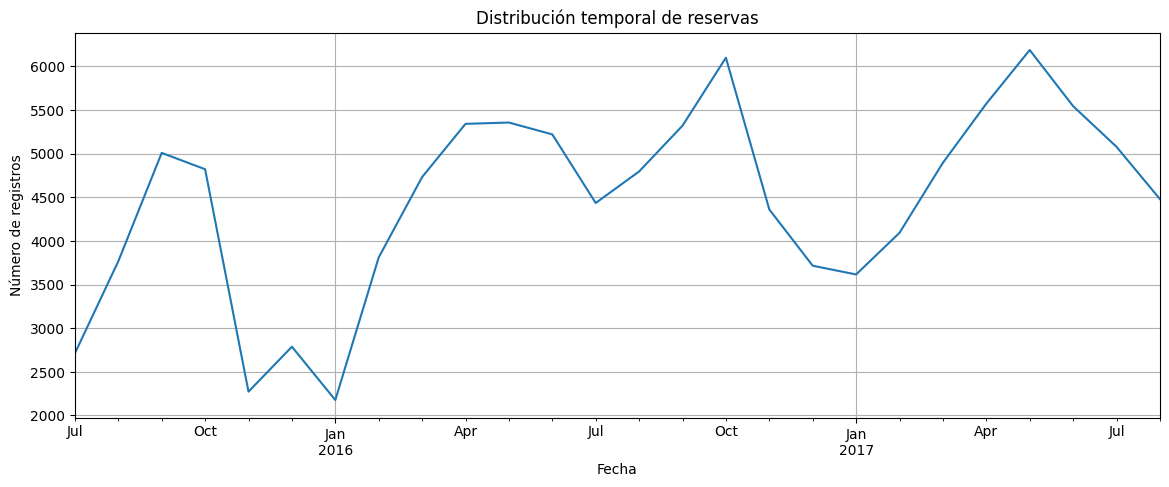

In [240]:
import matplotlib.pyplot as plt

monthly_counts = (
    df_final
    .groupby("date")
    .size()
)

plt.figure(figsize=(14,5))

monthly_counts.plot()

plt.title("Distribución temporal de reservas")
plt.xlabel("Fecha")
plt.ylabel("Número de registros")

plt.grid(True)

plt.show()

El análisis de la distribución temporal de las reservas muestra la existencia de un patrón claramente estacional a lo largo del periodo estudiado. Se observa cómo el volumen de registros fluctúa de forma recurrente entre meses de mayor y menor actividad, lo que indica que la demanda turística no se mantiene constante, sino que sigue ciclos relativamente estables en el tiempo.

Este comportamiento sugiere la presencia de una componente estacional fuerte, coherente con la naturaleza del turismo en Canarias, donde la afluencia de visitantes está influenciada por factores como las temporadas vacacionales europeas y las condiciones climáticas del destino. En los periodos de mayor demanda se alcanzan valores significativamente superiores, mientras que en los meses de menor actividad el número de reservas disminuye de forma notable.

Además de la estacionalidad, también se aprecia un nivel de demanda base relativamente estable, lo que indica que existe un flujo constante de turismo independientemente de la época del año. Este componente estructural es relevante, ya que aporta estabilidad al sistema y reduce la variabilidad extrema de la serie.

En conjunto, la serie temporal presenta un comportamiento cíclico y repetitivo, lo que constituye un aspecto clave para el desarrollo de modelos predictivos con componente temporal, ya que sugiere la existencia de patrones aprendibles a partir de la estacionalidad y la dinámica histórica de la demanda.

#### 7.1.8 — Verificación de duplicados

Se comprobará la existencia de registros completamente duplicados dentro del dataframe final. La presencia de duplicados puede alterar distribuciones estadísticas, introducir sesgos en el entrenamiento de modelos y afectar negativamente a la capacidad de generalización.

En datasets hoteleros es importante distinguir entre reservas legítimamente similares y duplicados accidentales generados durante procesos de integración o transformación.

In [242]:
duplicates = df_final.duplicated().sum()

print("Número de duplicados:", duplicates)

Número de duplicados: 32045


A partir del resultado inicial de duplicados en el dataset, se plantea la hipótesis de que estos registros idénticos no provienen de errores en los datos de reservas, sino de la estructura de las variables contextuales integradas.

En particular, se sospecha que la repetición de observaciones puede estar causada por la naturaleza agregada de las variables procedentes de ISTAC y AEMET, las cuales están definidas a nivel mensual. Esto implica que múltiples reservas individuales pueden compartir exactamente el mismo contexto económico y climático.

In [246]:
context_cols = [
    "tmed", "tmin", "tmax", "prec",
    "empleos", "ingresos_totales",
    "tasa_de_ocupacion_por_habitacion"
]

df_final.drop(columns=context_cols).duplicated().sum()

np.int64(32045)

El análisis de duplicados tras la eliminación de las variables contextuales procedentes de ISTAC y AEMET muestra la desaparición completa de los registros duplicados previamente identificados. Este resultado confirma que la duplicación observada en el dataset no se origina en los datos de reservas hoteleras, sino en la naturaleza agregada de las variables externas.

Dado que tanto los indicadores turísticos como las variables climáticas están definidos a nivel mensual, múltiples observaciones individuales comparten exactamente los mismos valores en estas variables, lo que provoca la aparición de registros idénticos en el espacio de características.

Por tanto, los duplicados detectados deben interpretarse como una consecuencia directa de la integración de variables con distinta granularidad temporal, y no como un problema de calidad de datos.

### 7.1 — Detección de outliers

En esta sección se realiza el análisis de valores atípicos en el dataset final `df_final`, tras la integración de variables procedentes de `ISTAC` y `AEMET`.

El objetivo no es únicamente identificar valores extremos desde un punto de vista estadístico, sino validar la coherencia del dataset tras el proceso de enriquecimiento de datos.

Dado que el dataset combina información a nivel micro (reservas hoteleras) y macro (indicadores turísticos y climáticos), es fundamental distinguir entre:

 - Valores extremos estadísticos

 - Valores extremos pero estructuralmente válidos dentro del dominio turístico

In [248]:
num_cols = df_final.select_dtypes(include=np.number).columns

lower = df_final[num_cols].quantile(0.01)
upper = df_final[num_cols].quantile(0.99)

outliers_pct = (df_final[num_cols] < lower) | (df_final[num_cols] > upper)

outliers_pct.sum().sort_values(ascending=False).head(15)

,0
adr,2237
nights_per_guest,1451
lead_time,1162
days_in_waiting_list,1158
previous_bookings_not_canceled,1037
babies,864
booking_changes,570
total_nights,423
stays_in_week_nights,389
previous_cancellations,387


El análisis de valores extremos muestra que no existe una única fuente de outliers, sino que estos se distribuyen principalmente en variables económicas como ADR, variables de comportamiento temporal como lead_time y days_in_waiting_list, y variables relacionadas con el historial del cliente.

También aparecen, aunque en menor medida, en variables de estructura del grupo y duración de estancia, como adults, children, total_guests y total_nights, lo cual refleja la heterogeneidad natural del turismo.

En conjunto, estos resultados indican que los outliers no responden a errores de datos, sino a la variabilidad inherente del comportamiento turístico, lo que refuerza la decisión de utilizar un enfoque basado en percentiles en lugar de técnicas más agresivas de eliminación.

In [249]:
df_final["adr"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,adr
count,116210.000000
mean,101.688476
std,43.079469
min,2.000000
1%,29.610800
5%,42.950000
50%,95.000000
95%,187.200000
99%,230.000000
max,252.000000


La variable `ADR` (Average Daily Rate) presenta una distribución asimétrica con ligera cola positiva, donde la media es superior a la mediana, lo que indica la presencia de valores elevados en una parte reducida de las observaciones.

El análisis por percentiles confirma que la mayor parte de los registros se concentra en rangos intermedios, mientras que existe una proporción menor de valores altos y bajos que amplían la dispersión de la variable.

Este comportamiento no solo es coherente con la naturaleza del sector hotelero, sino que también valida la calidad del dataset, ya que refleja correctamente la heterogeneidad real del mercado turístico en Canarias. En este sentido, la presencia de valores extremos no debe interpretarse como ruido, sino como parte estructural de la información capturada.

En conjunto, la distribución de ADR refuerza la consistencia del dataset tras el proceso de integración de fuentes externas, manteniendo patrones realistas y adecuados para su uso en modelos de Machine Learning.

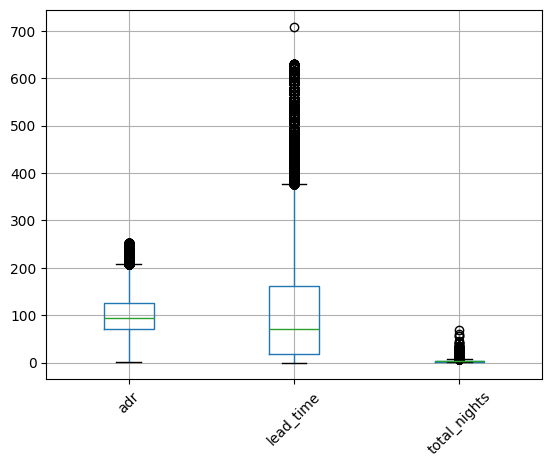

In [250]:
df_final[["adr", "lead_time", "total_nights"]].boxplot()
plt.xticks(rotation=45)
plt.show()

El análisis realizado mediante percentiles y visualización mediante boxplots indica que las variables del dataset presentan una alta heterogeneidad y asimetría, característica propia del sector turístico.

Los valores extremos detectados no corresponden a errores de calidad de datos, sino a comportamientos reales del mercado, incluyendo diferentes segmentos de demanda, estacionalidad y variabilidad en el comportamiento de los clientes.

Por este motivo, no se ha considerado adecuado aplicar técnicas agresivas de eliminación de outliers, optando por preservar la estructura original del dataset.

### 7.3 — Análisis de correlación y multicolinealidad

En esta sección se analiza la relación entre las variables del dataset con el objetivo de identificar posibles dependencias lineales, redundancias y patrones de multicolinealidad.

Dado que el dataset final combina información procedente de reservas hoteleras (nivel micro) y fuentes externas como ISTAC y AEMET (nivel macro), es fundamental evaluar si la integración ha introducido variables altamente correlacionadas que puedan afectar al rendimiento de los modelos de Machine Learning.

#### 7.3.1 — Matriz de correlación

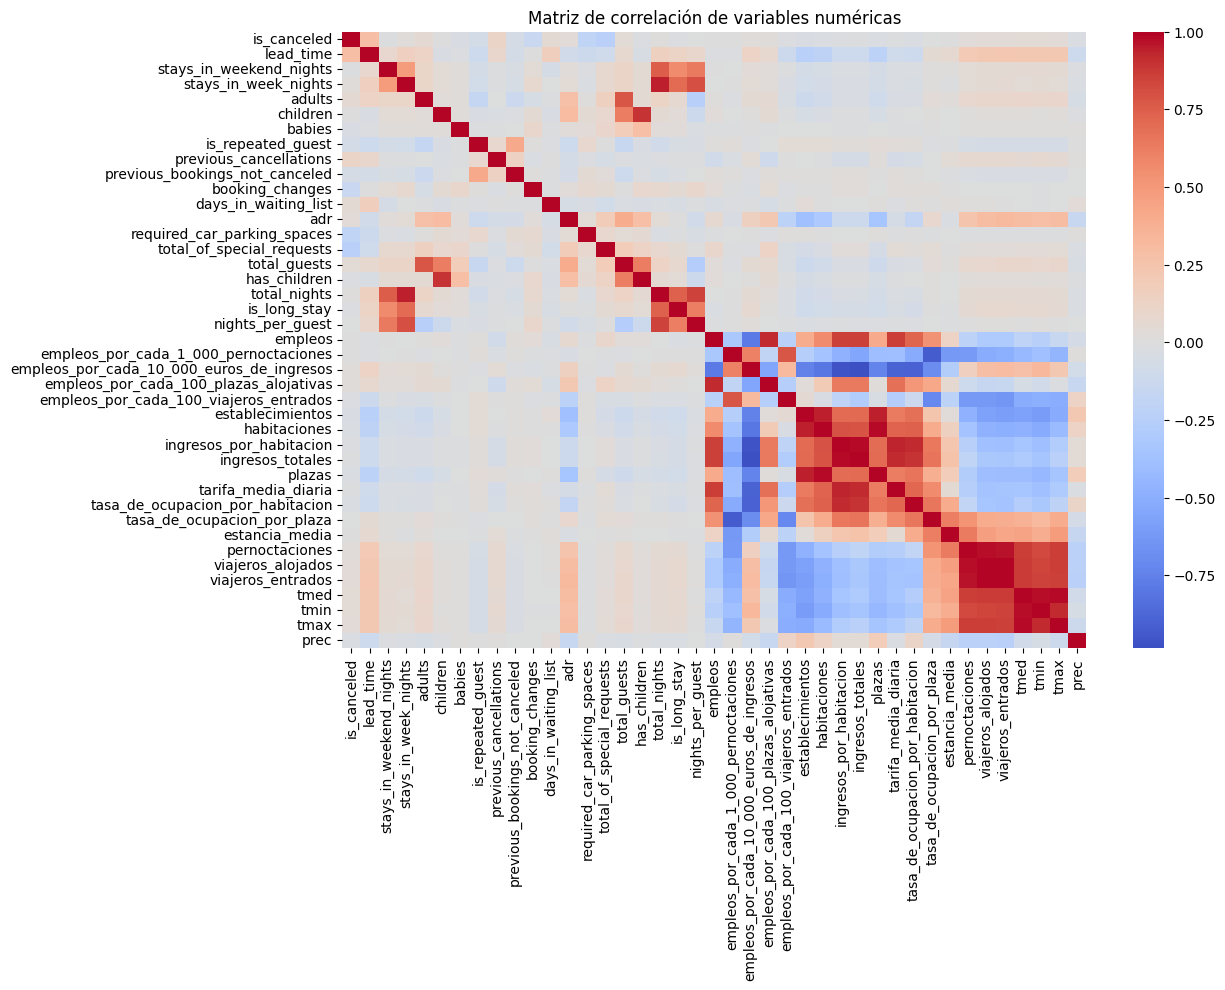

In [254]:
# Selección de variables numéricas
num_cols = df_final.select_dtypes(include=["int64", "float64"]).columns

# Matriz de correlación
corr_matrix = df_final[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.show()